# Goodreads Young Adult — EDA

This notebook is the analytical companion to `ingest/data/parquet/`. It does **two** things:

1. Explains the problems in the raw NDJSON that motivated the intermediate layer, and the design choices behind the 6-file Parquet split.
2. Profiles the data — sparsity, distributions, cold-start, long-tail — so the modeling pipeline downstream (`fusion/data/bundle/`) has an evidence base for its choices.

DuckDB does all aggregation directly over the Parquet files; pandas/NumPy are only used on the small results for plotting.

Sections: 1) setup · 2) why we split this way · 3) parquet layout & handoff to modeling · 4) overview & sparsity · 5) distributions · 6) cold-start & long-tail.

## 1. Setup

In [1]:
from pathlib import Path
import os, sys, time, textwrap

# --- project-root resolution via the .recsys-root sentinel (or $RECSYS_ROOT) ---
def find_root():
    env = os.environ.get("RECSYS_ROOT")
    if env:
        return Path(env).resolve()
    here = Path.cwd().resolve()
    for c in [here, *here.parents]:
        if (c / ".recsys-root").exists():
            return c
    return here

PROJECT_DIR = find_root()

# matplotlib/duckdb caches stay inside the repo (eda/data) so nothing pollutes $HOME.
NBCACHE = PROJECT_DIR / "eda" / "data" / ".notebook-cache"
(NBCACHE / "matplotlib").mkdir(parents=True, exist_ok=True)
(NBCACHE / "xdg").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NBCACHE / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NBCACHE / "xdg"))

'/home/jacky/zzz/recsys/eda/data/.notebook-cache/xdg'

In [2]:
import duckdb
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
print("duckdb", duckdb.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

duckdb 1.5.3 | pandas 2.3.3 | numpy 2.2.6


In [3]:
# --- paths (root-anchored; PROJECT_DIR resolved in the setup cell above) ---
DATA_DIR  = PROJECT_DIR / "data"
# Single source of truth for the raw-derived parquets — produced by
#   python ingest/src/duckdb_preprocess.py --build-only
INTER_DIR = PROJECT_DIR / "ingest" / "data" / "parquet"
print("Project     :", PROJECT_DIR)
print("Intermediate:", INTER_DIR)

Project     : /home/jacky/zzz/recsys
Intermediate: /home/jacky/zzz/recsys/ingest/data/parquet


In [4]:
import matplotlib as mpl

# --- modern, cohesive theme -------------------------------------------------
COLORS = {
    "blue": "#3B82F6", "teal": "#14B8A6", "coral": "#F43F5E", "amber": "#F59E0B",
    "purple": "#8B5CF6", "gray": "#64748B", "light_gray": "#E5E9F0",
    "ink": "#1E293B", "muted": "#64748B",
}
# default categorical cycle (used when a chart doesn\'t pick explicit colors)
PALETTE = [COLORS["blue"], COLORS["coral"], COLORS["teal"],
           COLORS["amber"], COLORS["purple"], COLORS["gray"]]

# Standard figure sizes -- small but high-dpi so they stay crisp & consistent.
# Every chart picks one of these so visual weight is uniform across the notebook.
FIG_SINGLE    = (7.2, 3.6)    # one chart
FIG_WIDE      = (8.6, 3.6)    # time series / wider x-axis
FIG_PANEL2    = (10.0, 3.6)   # two panels side-by-side
FIG_PANEL3    = (11.2, 3.4)   # three panels side-by-side
FIG_HBAR      = (7.4, 4.2)    # horizontal bar (top-N)
FIG_HBAR_TALL = (7.8, 5.2)    # horizontal bar with more rows

sns.set_theme(context="notebook", style="white")   # grid is drawn explicitly in polish()
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 140, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Ubuntu", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlelocation": "center", "axes.titlecolor": COLORS["ink"], "axes.titlepad": 12,
    "axes.labelsize": 10.5, "axes.labelcolor": COLORS["muted"], "axes.labelpad": 7,
    "axes.edgecolor": COLORS["light_gray"], "axes.linewidth": 1.0,
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.color": COLORS["ink"], "ytick.color": COLORS["ink"],
    "legend.frameon": False, "legend.fontsize": 8.5, "legend.handlelength": 1.4,
    "legend.borderaxespad": 0.6, "legend.labelspacing": 0.35,
    "axes.grid": False, "axes.axisbelow": True,
})

### 1.1 Raw NDJSON preview

Before diving into the parquet layer, glance at the three raw NDJSON files in `data/`. We stream just the first line of each file (no full read) and list every JSON attribute so the source schema is visible up front.

In [5]:
# Paths to the 3 raw NDJSON files. Used in two places:
#   1. duckdb_preprocess.py reads these to build intermediate/parquet/.
#   2. A handful of cells below (§5.2 non-English proxy) stream the raw
#      files for fields we intentionally don't carry in the parquet layer
#      (e.g., full review_text).
RAW_FILES = {
    "books":        DATA_DIR / "goodreads_books_young_adult.json",
    "reviews":      DATA_DIR / "goodreads_reviews_young_adult.json",
    "interactions": DATA_DIR / "goodreads_interactions_young_adult.json",
}
for name, p in RAW_FILES.items():
    assert p.exists(), f"missing {p}"

# Preview: read just the first line of each file and list its top-level JSON keys.
rows = []
for name, p in RAW_FILES.items():
    with open(p) as f:
        first = json.loads(f.readline())
    rows.append({"file": p.name,
                 "size_mb": round(p.stat().st_size/1024**2, 0),
                 "n_attrs": len(first),
                 "attrs": ", ".join(list(first.keys()))})
pd.DataFrame(rows)

,file,size_mb,n_attrs,attrs
0,goodreads_books_young_adult.json,469.0,29,"isbn, text_reviews_count, series, country_code, language_code, popular_shelves, asin, is_ebook, average_rating, kind..."
1,goodreads_reviews_young_adult.json,2628.0,11,"user_id, book_id, review_id, rating, review_text, date_added, date_updated, read_at, started_at, n_votes, n_comments"
2,goodreads_interactions_young_adult.json,11277.0,10,"user_id, book_id, review_id, is_read, rating, review_text_incomplete, date_added, date_updated, read_at, started_at"


### 1.2 Raw NDJSON attributes

A quick reference for every attribute in each of the three raw NDJSON files. Used as a lookup when reading subsequent EDA cells.

*`goodreads_books_young_adult.json`* — one row per **edition** (`book_id`):

| Attribute | Meaning |
|---|---|
| `book_id`                                                    | Edition-level Goodreads ID (one per hardcover / paperback / Kindle / translation). |
| `work_id`                                                    | Work-level ID — groups every edition of the same novel together. The §2 dedup hinges on this. |
| `title`, `title_without_series`                              | Display title, with/without the `(Series, #n)` suffix. |
| `isbn`, `isbn13`, `asin`, `kindle_asin`                      | External identifiers for the edition. Often empty for non-print formats. |
| `country_code`, `language_code`                              | Edition locale. `language_code` drives the Top-language plot in §5.1. |
| `description`                                                | Free-text book blurb. Source for the bge-small content embeddings. |
| `format`, `is_ebook`, `edition_information`                  | Hardcover / Paperback / Kindle / Audio / etc., and any "Special Edition" note. |
| `average_rating`, `ratings_count`, `text_reviews_count`      | Goodreads-aggregated popularity signals at the edition level. |
| `num_pages`                                                  | Page count (string in raw form; cast in the parquet layer). |
| `publication_year`, `publication_month`, `publication_day`   | Release date components. |
| `publisher`                                                  | Publisher name. |
| `series`                                                     | List of series IDs the edition belongs to. |
| `popular_shelves`                                            | Array of `{name, count}` — community-generated tags. Exploded into `book_shelves.parquet`. |
| `similar_books`                                              | Array of related `book_id`s computed by Goodreads. |
| `authors`                                                    | Array of `{author_id, role}`. Exploded into `book_authors.parquet`. |
| `url`, `link`, `image_url`                                   | Public Goodreads URLs and cover image. |

*`goodreads_interactions_young_adult.json`* — one row per **shelf action** (`user_id`, `book_id`). This is the full behavioural log:

| Attribute | Meaning |
|---|---|
| `user_id`, `book_id`              | Composite key. Note `book_id` is edition-level — collapsed to `work_id` downstream. |
| `review_id`                       | Links to the reviews file when a free-text review was written (~7% of rows). |
| `is_read`                         | Boolean — did the user move the book to a "read" shelf? Primary implicit positive signal. |
| `rating`                          | 1–5 stars. `0` means no explicit rating was given (still possibly read/shelved). |
| `review_text_incomplete`          | A short snippet only; the full review text lives in the reviews file. |
| `date_added`, `date_updated`      | When the shelf row was first created / last edited (string timestamps). |
| `read_at`, `started_at`           | Self-reported reading window. Often blank. |

*`goodreads_reviews_young_adult.json`* — the ~7% subset of interactions that carry **full review text** (`review_id`):

| Attribute | Meaning |
|---|---|
| `user_id`, `book_id`, `review_id` | Same keys as the interactions file. |
| `rating`                          | Star rating attached to the review (may be `0` for unrated text). |
| `review_text`                     | The full free-text review. Source for the LLM taste-profile pipeline. |
| `date_added`, `date_updated`      | Lifecycle timestamps of the review. |
| `read_at`, `started_at`           | Self-reported reading window. |
| `n_votes`, `n_comments`           | Community engagement on the review itself. |

Two callouts to keep in mind for the rest of the notebook:

- **Edition vs work.** `book_id` is the edition; `work_id` is the abstract novel. 
- **Interactions vs reviews overlap.** The two files share `user_id`, `book_id`, `rating`, `date_added` etc., but `interactions` is the full log (~34.9M rows) and `reviews` is the text-bearing subset (~2.4M rows). They are *not* joined automatically — joining naively would drop the ~93% of interactions that have no review.

In [6]:
con = duckdb.connect()
con.execute(f"SET threads TO {max(1, (os.cpu_count() or 4) - 1)}")
con.execute("SET preserve_insertion_order=false")

def qs(x):                       # quote a path or string literal for SQL
    return "'" + str(x).replace("'", "''") + "'"

# All 6 parquets in intermediate/. Each gets a direct DuckDB view in the
# next cell so SQL stays one-liners (e.g. `SELECT count(*) FROM interactions`).
SRC = {
    "books":        INTER_DIR / "books_core.parquet",
    "book_authors": INTER_DIR / "book_authors.parquet",
    "book_shelves": INTER_DIR / "book_shelves.parquet",
    "book_series":  INTER_DIR / "book_series.parquet",
    "reviews":      INTER_DIR / "reviews_core.parquet",
    "interactions": INTER_DIR / "interactions_core.parquet",
}
for name, p in SRC.items():
    assert p.exists(), f"missing {p} -- run `python ingest/src/duckdb_preprocess.py --build-only`"
pd.DataFrame({"file":[p.name for p in SRC.values()],
              "size_mb":[round(p.stat().st_size/1024**2,1) for p in SRC.values()]})


,file,size_mb
0,books_core.parquet,36.4
1,book_authors.parquet,0.9
2,book_shelves.parquet,29.7
3,book_series.parquet,0.4
4,reviews_core.parquet,102.0
5,interactions_core.parquet,1190.7


### 1.3 DuckDB views & helpers

A DuckDB **view** is just a saved query — `CREATE VIEW books AS SELECT ... FROM read_parquet('.../books_core.parquet')` lets the rest of the notebook write `SELECT * FROM books` instead of repeating the full `read_parquet(...)` path on every cell. No data is copied; the view is a lazy alias and DuckDB still streams from the parquet on each query (predicate pushdown and row-group skipping still apply).

Why bother creating views instead of querying the parquet paths directly:

- **Readability** — all subsequent EDA SQL fits on one line: `q("SELECT count(*) FROM interactions")`.
- **Projection** — each view exposes only the columns this notebook actually needs. For example the `interactions` view drops the 6 columns related to review-text and timestamps other than `date_added`, leaving just `user_id, book_id, rating, is_read, date_added`. Smaller `SELECT *` output, clearer intent — what's on disk is untouched.
- **Light derivation** — some views add columns that don't exist in the parquet: `books.has_description = coalesce(description_len, 0) > 0` synthesizes a boolean, and `work_series` (below) is a fully derived view, not a parquet at all.

**6 parquets on disk → 7 views here.** The mapping is *6 direct + 1 derived*:

*6 direct views, one per parquet in `intermediate/parquet/`.*

| View | Backing parquet | What's projected |
|---|---|---|
| `books`        | `books_core.parquet`        | `book_id`, `work_id`, identity + numeric meta, derived `has_description` |
| `book_authors` | `book_authors.parquet`      | `book_id`, `author_id`, `role` — full passthrough |
| `book_shelves` | `book_shelves.parquet`      | `book_id`, `shelf_name`, `shelf_count` — kept full because §5.1 / §5.4 visualise raw shelf noise |
| `book_series`  | `book_series.parquet`       | `book_id`, `series_id` — the edition-level series membership |
| `reviews`      | `reviews_core.parquet`      | `user_id`, `book_id`, `rating`, `review_text_len`, `has_review_text` |
| `interactions` | `interactions_core.parquet` | `user_id`, `book_id`, `rating`, `is_read`, `date_added` |

*1 derived view — `work_series` — joined on the fly from `books` and `book_series`. It has no parquet backing.*

| View | Definition | Why |
|---|---|---|
| `work_series` | `SELECT DISTINCT b.work_id, bs.series_id FROM books b JOIN book_series bs USING (book_id) WHERE b.work_id IS NOT NULL` | Collapses edition-level `book_series` to **work level**. The 126 editions of *The Hunger Games* all carry `series_id=339872`; this view shows that as **one row** `(work_id=2792775, series_id=339872)`. Use `book_series` when you care about which edition; use `work_series` for everything else. Of 16,723 multi-edition works, only a small fraction have any cross-edition `series` disagreement (see §3.3); `DISTINCT` over the union handles them correctly. |

So **6 direct + 1 derived = 7 total views**, against 6 parquets on disk. The sanity check at the bottom of the next cell runs a row-count across every view — if any path is wrong or the join breaks, that one query fails fast before §2 starts.

The second cell defines plotting utilities (`human()` for K/M/B number formatting, `polish()` for axis styling, `hbar()` for horizontal bar charts). Pure presentation helpers — no data touched here.

In [7]:
def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).fetchdf()

# --- direct views over each parquet ------------------------------------------
# `has_description` is the only derived column on books (intermediate stores
# raw description text + its length, but no boolean).
con.execute(f"""CREATE OR REPLACE VIEW books AS SELECT
        book_id, work_id, title, language_code,
        try_cast(average_rating AS DOUBLE)        AS average_rating,
        try_cast(num_pages AS INTEGER)            AS num_pages,
        try_cast(publication_year AS INTEGER)     AS publication_year,
        coalesce(description_len, 0) > 0          AS has_description,
        series_count, popular_shelves_count, authors_count
    FROM read_parquet({qs(SRC['books'])})""")

con.execute(f"""CREATE OR REPLACE VIEW book_authors AS
    SELECT book_id, author_id, role
    FROM read_parquet({qs(SRC['book_authors'])})""")

con.execute(f"""CREATE OR REPLACE VIEW book_shelves AS
    SELECT book_id, shelf_name, shelf_count
    FROM read_parquet({qs(SRC['book_shelves'])})""")

con.execute(f"""CREATE OR REPLACE VIEW book_series AS
    SELECT book_id, series_id
    FROM read_parquet({qs(SRC['book_series'])})""")

con.execute(f"""CREATE OR REPLACE VIEW reviews AS
    SELECT user_id, book_id, rating, review_text_len, has_review_text
    FROM read_parquet({qs(SRC['reviews'])})""")

con.execute(f"""CREATE OR REPLACE VIEW interactions AS
    SELECT user_id, book_id, rating, is_read, date_added
    FROM read_parquet({qs(SRC['interactions'])})""")

# --- derived: work-level series membership -----------------------------------
# Collapses edition-level book_series via DISTINCT join. The DISTINCT is what
# tolerates the 2 rare cases of cross-edition disagreement (both are
# "one edition missing, others populated" -- safe to take the union).
con.execute("""CREATE OR REPLACE VIEW work_series AS
    SELECT DISTINCT b.work_id, bs.series_id
    FROM books b JOIN book_series bs USING (book_id)
    WHERE b.work_id IS NOT NULL AND b.work_id <> ''""")

# Sanity check: row counts across every view.
q("""SELECT 'books'         AS view, count(*) AS n_rows FROM books
UNION ALL SELECT 'book_authors',    count(*) FROM book_authors
UNION ALL SELECT 'book_shelves',    count(*) FROM book_shelves
UNION ALL SELECT 'book_series',     count(*) FROM book_series
UNION ALL SELECT 'work_series',     count(*) FROM work_series
UNION ALL SELECT 'reviews',         count(*) FROM reviews
UNION ALL SELECT 'interactions',    count(*) FROM interactions""")


,view,n_rows
0,books,93398
1,book_authors,117722
2,book_shelves,8169368
3,book_series,58247
4,work_series,17614
5,reviews,2389900
6,interactions,34919254


In [8]:
def human(v):
    v = float(v)
    for unit, scale in (("B", 1e9), ("M", 1e6), ("K", 1e3)):
        if abs(v) >= scale:
            return f"{v/scale:.1f}{unit}"
    return f"{v:.0f}"

def wrapped(values, width=32):
    return [textwrap.fill(str(v), width=width) for v in values]

def polish(ax, title, xlabel=None, ylabel=None, grid_axis="y"):
    # centered, bold title (modern look); muted axis labels; clean spines & ticks.
    ax.set_title(title, loc="center", pad=12, fontweight="bold", color=COLORS["ink"])
    if xlabel is not None: ax.set_xlabel(xlabel, labelpad=7, color=COLORS["muted"])
    if ylabel is not None: ax.set_ylabel(ylabel, labelpad=7, color=COLORS["muted"])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(COLORS["light_gray"]); ax.spines[side].set_linewidth(1.0)
    ax.grid(False)
    ax.grid(axis=grid_axis, color=COLORS["light_gray"], linewidth=0.9, alpha=0.9)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors=COLORS["ink"])   # drop tick marks; keep labels

def hbar(df, label_col, value_col, title, xlabel, color, max_items=12, wrap_width=30):
    data = df.nlargest(max_items, value_col).sort_values(value_col)
    figsize = FIG_HBAR if len(data) <= 10 else FIG_HBAR_TALL
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(wrapped(data[label_col], wrap_width), data[value_col], color=color)
    ax.bar_label(bars, labels=[human(v) for v in data[value_col]], padding=4,
                 fontsize=8, color=COLORS["ink"])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
    polish(ax, title, xlabel=xlabel, grid_axis="x")
    ax.tick_params(axis="y", labelsize=8); ax.margins(x=0.15); plt.tight_layout()
    return fig

## 2. From raw data to the parquet layer

Before any visualisation, two structural problems in the raw NDJSON have to be acknowledged — they are the reason the intermediate layer exists in its current shape.

Goodreads exposes books at two granularities:

- `book_id` — **edition-level** (hardcover / paperback / Kindle / audio / UK edition / French translation each get a separate id).
- `work_id` — **work-level** (the abstract novel, regardless of edition).

If we feed `book_id` directly into the model, every edition of *The Hunger Games* is a different item: collaborative signal dilutes, cold-start gets worse, and any time-based split risks training on one edition and evaluating on another.

### 2.1 How many editions does a single work have?

In [9]:
# Read intermediate parquet directly: the `books` view doesn't project `format` etc.
BOOKS_RAW = INTER_DIR / "books_core.parquet"

top_works = q(f'''
    SELECT work_id, count(*) AS n_editions, max(title) AS sample_title
    FROM read_parquet({qs(BOOKS_RAW)})
    WHERE work_id IS NOT NULL AND work_id <> ''
    GROUP BY work_id
    ORDER BY n_editions DESC
    LIMIT 5
''')
top_works

,work_id,n_editions,sample_title
0,2792775,126,"饥饿游戏 (The Hunger Games, #1)"
1,16827462,119,ბედის ვარსკვლავის ბრალია
2,2267189,112,"ძვლების ქალაქი (The Mortal Instruments, #1)"
3,8812783,100,زاغ مقلد - عطش مبارزه جلد سوم
4,6171458,100,اشتعال - عطش مبارزه جلد2


*The Hunger Games* tops the list with **126 editions**. Looking at its top rows shows what we are dealing with:

In [10]:
demo_work = top_works.iloc[0]['work_id']  # The Hunger Games

editions = q(f'''
    SELECT book_id, title, language_code, format,
           publication_year, num_pages, ratings_count
    FROM read_parquet({qs(BOOKS_RAW)})
    WHERE work_id = {qs(demo_work)}
    ORDER BY ratings_count DESC NULLS LAST
    LIMIT 12
''')
editions

,book_id,title,language_code,format,publication_year,num_pages,ratings_count
0,2767052,"The Hunger Games (The Hunger Games, #1)",eng,Hardcover,2008,374,4899965
1,18626858,"The Hunger Games (The Hunger Games, #1)",eng,None,<NA>,387,54842
2,7285601,"The Hunger Games (The Hunger Games, #1)",en-US,Paperback,2010,374,23001
3,7723926,"The Hunger Games (The Hunger Games, #1)",eng,Kindle Edition,2009,387,11358
4,12885649,"The Hunger Games (The Hunger Games, #1)",en-GB,Paperback,2011,454,8658
5,6596839,"Los juegos del hambre (Los juegos del hambre, #1)",spa,Paperback,2009,396,8370
6,6053292,"The Hunger Games (The Hunger Games, #1)",en-GB,Paperback,2009,436,7425
7,12091570,"The Hunger Games (The Hunger Games, #1)",eng,Paperback,2009,436,6622
8,7107665,"The Hunger Games (The Hunger Games, #1)",eng,ebook,2009,358,5426
9,6490389,"Tödliche Spiele (Die Tribute von Panem, #1)",ger,Hardcover,2009,416,4086


Hardcover, paperback, Kindle, Audible, Audio CD; Norwegian, Finnish, Slovak translations. Same novel, different `book_id`. Without merging, the model treats these as 12 unrelated items.

### 2.2 How common is the multi-edition pattern?

Group every work by **how many editions it has** (`1`, `2-3`, `4-5`, `6-10`, `>10`). The two panels below answer two different questions about that same bucketing:

- **Left (blue)** — *how many distinct works fall in each bucket?* This is the count of novels.
- **Right (coral)** — *how many raw `book_id` rows do those works contribute?* This is the count of edition rows you'd actually see in `books_core.parquet`.

A 1-edition work contributes 1 row; a 50-edition work contributes 50 rows. So if the two panels disagree, it means a small slice of works is responsible for a disproportionate share of the raw rows.

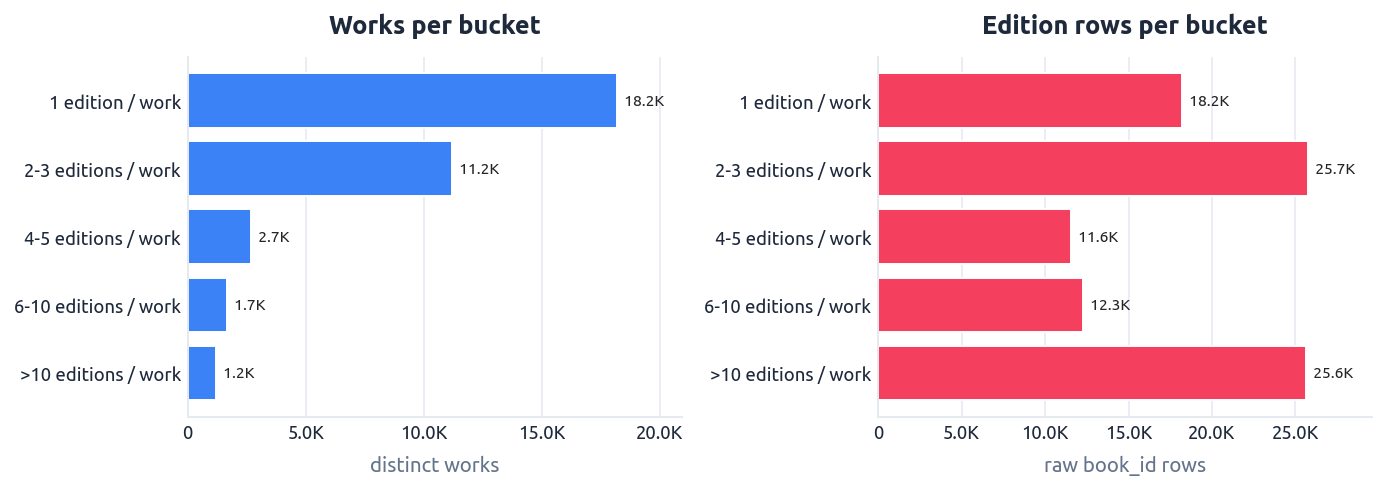

,bucket,n_works,n_editions
0,1 edition / work,18193,18193.0
1,2-3 editions / work,11190,25730.0
2,4-5 editions / work,2661,11568.0
3,6-10 editions / work,1662,12258.0
4,>10 editions / work,1210,25649.0


In [11]:
edition_dist = q(f"""
    SELECT bucket, n_works, n_editions
    FROM (
        SELECT CASE
                   WHEN n = 1               THEN '1 edition / work'
                   WHEN n BETWEEN 2 AND 3   THEN '2-3 editions / work'
                   WHEN n BETWEEN 4 AND 5   THEN '4-5 editions / work'
                   WHEN n BETWEEN 6 AND 10  THEN '6-10 editions / work'
                   ELSE '>10 editions / work'
               END AS bucket,
               count(*) AS n_works,
               sum(n)   AS n_editions,
               min(n)   AS _ord
        FROM (SELECT work_id, count(*) AS n
              FROM read_parquet({qs(BOOKS_RAW)})
              WHERE work_id IS NOT NULL AND work_id <> ''
              GROUP BY 1)
        GROUP BY 1
    )
    ORDER BY _ord
""")

fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL2)

axes[0].barh(edition_dist['bucket'], edition_dist['n_works'], color=COLORS['blue'])
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: human(v)))
for i, v in enumerate(edition_dist['n_works']):
    axes[0].text(v, i, f"  {human(v)}", va='center', fontsize=8)
polish(axes[0], "Works per bucket", "distinct works", grid_axis="x")

axes[1].barh(edition_dist['bucket'], edition_dist['n_editions'], color=COLORS['coral'])
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: human(v)))
for i, v in enumerate(edition_dist['n_editions']):
    axes[1].text(v, i, f"  {human(v)}", va='center', fontsize=8)
polish(axes[1], "Edition rows per bucket", "raw book_id rows", grid_axis="x")

for ax in axes:
    ax.margins(x=0.15)

plt.tight_layout(); plt.show()
edition_dist

Compare the two panels: the **blue bar for `1 edition / work` is the tallest on the left** (over half of all works) but the corresponding coral bar on the right is much shorter — those single-edition works only emit one `book_id` row each. Meanwhile the `>10 editions / work` bucket is tiny on the left (~3.5% of works) yet contributes the largest coral bar on the right (~33% of all edition rows).

**Conclusion: multi-edition concentrates exactly on the popular head** — the part where collaborative signal matters most. That's the slice we're consolidating when we collapse `book_id` → `work_id`.

### 2.2 The same duplication, seen at the user level

In [12]:
INTER_RAW = INTER_DIR / "interactions_core.parquet"

# User with the most rows on the demo work (The Hunger Games).
demo_user = q(f'''
    SELECT i.user_id, count(*) AS n_rows
    FROM read_parquet({qs(INTER_RAW)}) i
    JOIN read_parquet({qs(BOOKS_RAW)}) b USING (book_id)
    WHERE b.work_id = {qs(demo_work)}
    GROUP BY 1
    ORDER BY n_rows DESC
    LIMIT 1
''').iloc[0]['user_id']

user_rows = q(f'''
    SELECT i.book_id, b.title, b.format, b.language_code,
           i.rating, i.is_read, i.date_added
    FROM read_parquet({qs(INTER_RAW)}) i
    JOIN read_parquet({qs(BOOKS_RAW)}) b USING (book_id)
    WHERE i.user_id = {qs(demo_user)} AND b.work_id = {qs(demo_work)}
    ORDER BY i.date_added
''')
print(f'user_id = {demo_user[:8]}...  all raw rows for work {demo_work} (The Hunger Games):')
user_rows

user_id = 13a6c5f1...  all raw rows for work 2792775 (The Hunger Games):


,book_id,title,format,language_code,rating,is_read,date_added
0,2767052,"The Hunger Games (The Hunger Games, #1)",Hardcover,eng,4,True,2009-11-17 13:10:32+00:00
1,6053292,"The Hunger Games (The Hunger Games, #1)",Paperback,en-GB,5,True,2010-01-16 20:43:00+00:00
2,3544003,"The Hunger Games (The Hunger Games, #1)",Audio CD,eng,4,True,2010-01-16 20:43:03+00:00
3,6080900,"The Hunger Games (The Hunger Games, #1)",Audio CD,en-US,4,True,2010-01-16 20:43:05+00:00
4,5670194,"The Hunger Games (The Hunger Games, #1)",Audiobook,eng,4,True,2010-01-16 20:43:06+00:00
5,7077211,"The Hunger Games (The Hunger Games, #1)",Mass Market Paperback,ind,4,True,2010-01-16 20:43:08+00:00
6,6772333,"The Hunger Games (The Hunger Games, #1)",Paperback,eng,4,True,2010-01-16 20:43:10+00:00
7,6490389,"Tödliche Spiele (Die Tribute von Panem, #1)",Hardcover,ger,4,True,2010-01-16 20:43:15+00:00
8,6902967,Hunger Games (Hunger Games #1),Paperback,fre,4,True,2010-01-16 20:43:19+00:00
9,6530628,"Igrzyska śmierci (Igrzyska śmierci, #1)",Paperback,pol,4,True,2010-01-16 20:43:26+00:00


All rows are the same user on the same work, just split across editions. Without dedup, the `(user, work)` pair gets sampled N times during training and counted N times in popularity.

The aggregation rule when collapsing edition rows into a single `(uid, iid)` row:

| Column | Aggregation | Rationale |
|---|---|---|
| `is_read`     | `OR`              | Any edition read → work has been read. |
| `rating`      | First non-zero    | Keep an explicit rating if one exists. |
| `is_positive` | Recompute `rating>=4 OR is_read` | Label stays consistent with the rule. |
| `ts`          | `min(date_added)` | First contact with the work — the most informative timestamp. |

### 2.4 How much is collapsed across the full dataset?

In [13]:
dedup_stats = q(f'''
    WITH joined AS (
        SELECT i.user_id, b.work_id, count(*) AS n_rows
        FROM read_parquet({qs(INTER_RAW)}) i
        JOIN read_parquet({qs(BOOKS_RAW)}) b USING (book_id)
        WHERE b.work_id IS NOT NULL AND b.work_id <> ''
        GROUP BY 1, 2
    )
    SELECT sum(n_rows)                                        AS raw_rows,
           count(*)                                            AS unique_pairs,
           sum(CASE WHEN n_rows = 1  THEN 1 ELSE 0 END)        AS single_edition_pairs,
           sum(CASE WHEN n_rows >= 2 THEN 1 ELSE 0 END)        AS multi_edition_pairs,
           sum(CASE WHEN n_rows >= 2 THEN n_rows-1 ELSE 0 END) AS rows_collapsed
    FROM joined
''').iloc[0]

pd.DataFrame({
    'metric': ['raw (user, work) rows',
               'unique (uid, iid) pairs after dedup',
               'pairs with a single edition',
               'pairs with >=2 editions',
               'rows collapsed (duplicates removed)'],
    'count':  [int(dedup_stats['raw_rows']),
               int(dedup_stats['unique_pairs']),
               int(dedup_stats['single_edition_pairs']),
               int(dedup_stats['multi_edition_pairs']),
               int(dedup_stats['rows_collapsed'])],
    'share':  ['100.00%',
               f"{dedup_stats['unique_pairs']/dedup_stats['raw_rows']*100:.2f}%",
               f"{dedup_stats['single_edition_pairs']/dedup_stats['unique_pairs']*100:.2f}%",
               f"{dedup_stats['multi_edition_pairs']/dedup_stats['unique_pairs']*100:.2f}%",
               f"{dedup_stats['rows_collapsed']/dedup_stats['raw_rows']*100:.2f}%"],
})

,metric,count,share
0,"raw (user, work) rows",34919254,100.00%
1,"unique (uid, iid) pairs after dedup",34618729,99.14%
2,pairs with a single edition,34325166,99.15%
3,pairs with >=2 editions,293563,0.85%
4,rows collapsed (duplicates removed),300525,0.86%


About **300K rows collapse** — <1% in absolute terms, but concentrated on the head. Skipping this step:

- Inflates popularity for hot items (recommendation feedback loop becomes worse).
- Adds noise to item-item co-occurrence (different editions of the same book should be identical, not similar).
- Leaks across the time split (test row = hardcover; train rows = paperback of the same book).

### 2.5 Before / after summary

In [14]:
summary = q(f'''
    SELECT
        (SELECT count(*) FROM read_parquet({qs(BOOKS_RAW)}))                       AS n_book_id,
        (SELECT count(DISTINCT work_id) FROM read_parquet({qs(BOOKS_RAW)})
          WHERE work_id IS NOT NULL AND work_id <> '')                              AS n_work_id,
        (SELECT count(*) FROM read_parquet({qs(INTER_RAW)}))                        AS n_raw_inter,
        (SELECT count(DISTINCT user_id) FROM read_parquet({qs(INTER_RAW)}))         AS n_user
''').iloc[0]

before_density = summary['n_raw_inter'] / (summary['n_user'] * summary['n_book_id']) * 100
after_density  = int(dedup_stats['unique_pairs']) / (summary['n_user'] * summary['n_work_id']) * 100

pd.DataFrame({
    'dimension':           ['items (book_id / iid)', 'users', 'interaction rows', 'matrix density'],
    'before merge+dedup':  [f"{summary['n_book_id']:,}",
                            f"{summary['n_user']:,}",
                            f"{summary['n_raw_inter']:,}",
                            f"{before_density:.4f}%"],
    'after merge+dedup':   [f"{summary['n_work_id']:,}",
                            f"{summary['n_user']:,}",
                            f"{int(dedup_stats['unique_pairs']):,}",
                            f"{after_density:.4f}%"],
})

,dimension,before merge+dedup,after merge+dedup
0,items (book_id / iid),"93,398","34,916"
1,users,"644,686","644,686"
2,interaction rows,"34,919,254","34,618,729"
3,matrix density,0.0580%,0.1538%


Items drop by **63%** (93.4K → 34.9K) and matrix density roughly **doubles** (~0.029% → ~0.058%). This is free densification — we are only recovering the natural granularity, not synthesizing anything.

## 3. Parquet layout and handoff to modeling

§2 explained *why* the intermediate layer exists. This section answers three questions the model team will ask:

1. **What is in each of the 6 parquets?** (3.1)
2. **How do `book_id` / `work_id` / `series_id` / `iid` / `uid` relate?** (3.2)
3. **What edge cases bite us downstream?** (3.3)

…followed by the design rationale and the handoff contract with `bundle/`.

### 3.1 The 6 parquets at a glance

| File | Rows | Primary key | Source field | Notes |
|---|---:|---|---|---|
| `books_core.parquet`        | 93,398     | `book_id`              | `books.json` scalars                       | 30 columns. Carries `work_id`, `title`, `description` (+`description_len`), `language_code`, `format`, `publication_year`, `average_rating`, `ratings_count`, `series_count`, `authors_count`, `popular_shelves_count`, etc. Source of the bge-small content embedding. |
| `book_authors.parquet`      | 117,722    | `(book_id, author_id)` | `books.json.authors[]` exploded            | Carries `role` (`Author` / `Illustrator` / `Translator` / …). One row per (edition, author). |
| `book_shelves.parquet`      | 8,169,368  | `(book_id, shelf_name)`| `books.json.popular_shelves[]` exploded    | Largest table. `shelf_count` = number of users who tagged that edition with that shelf. ~217K distinct shelf names — vocab cleanup in §5.4. |
| `book_series.parquet`       | 58,247     | `(book_id, series_id)` | `books.json.series[]` exploded             | 51,888 books in exactly 1 series; 2,752 in 2 – 4 series (omnibus + subseries). Coverage: 54,640 / 93,398 books = 58.5%. |
| `reviews_core.parquet`      | 2,389,900  | `review_id`            | `reviews.json` (independent file)          | **No `review_text` column** — only `review_text_len` and `has_review_text`. Full text is consumed by `llm_profiles.py` directly from the raw NDJSON. |
| `interactions_core.parquet` | 34,919,254 | `(user_id, book_id)`   | `interactions.json` (independent file)     | Full behavioural log. `rating ∈ {0..5}` where `0` = no explicit rating. `is_read` = was moved to a "read" shelf. |

### 3.2 Identifier hierarchy

Three layers of IDs, mapped from raw NDJSON into the bundle:

```
                    raw / intermediate            bundle / model-ready
                    ─────────────────────         ────────────────────────────────
   user            user_id (str)            ───▶  uid (int32)      [id_maps/uid_map.parquet]
   work            work_id (str)            ─┐
   edition         book_id (str)            ─┴─▶  iid (int32)      [id_maps/book_iid_map.parquet]
   author          author_id (str)          ───▶  kept as str in book_features.author_id_primary
   series          series_id (str)          ───▶  kept as str in book_features.series_id
   shelf           shelf_name (str)         ───▶  curated into 16-d genre vector + tag vocab
```

Key facts:

- **`book_id` is edition-level**; **`work_id` is work-level**. *The Hunger Games* has 126 different `book_id`s but 1 `work_id`.
- **`iid` ≡ `work_id` reassigned to int32.** 93,398 → 34,916 (every `book_id` of the same work maps to the same `iid`).
- **`author_id` and `series_id`** stay as strings into the bundle — their cardinality is small enough that the modeling code uses them directly as categorical keys (top-20K kept; rest go to `<other>` in `categorical_vocabs.json`).
- **`shelf_name`** is free-form text and never used directly downstream; it's a *source*, not an ID.

### 3.3 Multi-valued attributes & caveats

A handful of "natural keys" are silently multi-valued. Be explicit about which side you're operating on:

- **A book has multiple authors.** Most do. `book_authors` exposes the full set; the bundle's `book_features.author_id_primary` keeps only the first one + the full list in `author_ids`.
- **A book can belong to multiple series.** 4.7% of books (≈2,752 out of 58,500 in-series) are in 2 – 4 series (e.g. omnibus + subseries). `book_series` keeps them all; the bundle picks the first.
- **Editions of the same work can have *different* `series_id`s.** This is the subtle one. 96.2% of multi-edition works have consistent series across editions; **3.8% (641 works) do not**. Example: *Street Magic (The Circle Opens #2)* — different editions are tagged "The Circle Opens", "Tortall Universe", or a country-specific series.
  - The `work_series` view (defined in §1.3) does `SELECT DISTINCT b.work_id, bs.series_id` — so a work with 3 series_ids becomes 3 rows in this view. **Do not** naively `GROUP BY work_id` and pick one without knowing which — the bundle explicitly chooses *first listed*. Document the choice when consuming downstream.
- **A book has dozens of shelves.** Mostly noise (reading status, generic, misspellings). §5.4 shows just how noisy. Only the curated 16-d genre projection is used in `bundle/features/book_features.genre_*`.

Cross-table caveats:

- **`reviews_core` and `interactions_core` overlap in keys but are NOT the same data.** Interactions = full behaviour log (34.9M); reviews = text subset (2.4M, ~7%). Joining naively drops ~93% of interactions. If you want "interactions with text", `LEFT JOIN` on `review_id` and keep the unmatched ones.
- **`books_core.series_count` ≠ `count(*)` from `book_series` for the same `book_id`.** `series_count` is the raw `len(series)` in the JSON; `book_series` is the explosion. They agree per-row, but exist for different access patterns (filter vs. join).

### 3.4 Design choices

**Column projection — keep all raw columns.** `books_core` has 30 columns but modeling only uses ~10. The rest (`isbn`, `asin`, `url`, `image_url`, …) are retained so audits and new feature derivations don't need to re-parse the 12 GB NDJSON. The cost is 38 MB.

**Array explosion — `authors`, `popular_shelves`, `series` get their own m2m parquets.** `similar_books` is kept only as a count (`similar_books_count`) because no downstream consumer needs the per-edge edges; if a future content-similarity channel wants them, the explosion follows the same template.

**Row-level deduplication — deliberately not done here.** Intermediate keeps every raw row. The `(uid, iid)` dedup from §2 happens in the bundle layer (`build_tables.py`), where the downstream task can pick its own aggregation rule.

**Compression — ZSTD.** DuckDB's default; ~20–30% smaller than SNAPPY at a <5% read-speed cost.

**Row groups — DuckDB defaults.** `interactions_core` ends up with 352 row groups (~122,880 rows each), `books_core` with 2. Full scans pay nothing; predicate pushdown can skip row groups automatically. No manual tuning needed.

**No sorting, no partitioning.** Partitioning helps only when downstream queries reliably filter on a key. Both EDA and the bundle pipeline are full-scan workloads — partitioning would add complexity without payback. If `interactions_core` ever grew to ~120 GB, partitioning by `year(date_added)` would be worth revisiting.

**Schema evolution.** Parquet makes adding columns cheap (new files add them; old files read as null) and removing columns expensive (full rewrite). Bias toward keeping columns rather than trimming aggressively.

### 3.5 Is the current split appropriate?

For the multi-channel recall recsys downstream, yes:

- ✅ The 6-file shape matches the upstream NDJSON structure 1:1 (3 `*_core` tables + 3 m2m explosions), so the parser stays simple and the cache is easy to rebuild (~90s end-to-end).
- ✅ Both EDA and the bundle pipeline read the same files — no drift between exploration and modeling.
- ✅ Keeping the merge/dedup out of intermediate preserves optionality: i2i wants OR-aggregation on `is_read`; a sequential model might want every raw row in temporal order. Pushing the decision to the consumer is the right default.
- ✅ With `book_series` added, every nested array we care about for content modeling is reachable via a `read_parquet + JOIN` instead of re-parsing the NDJSON.
- ⚠️ `book_authors` and `book_series` are both small (≤120K rows / ≤1 MB) and could in principle be folded back into `books_core` as `LIST` columns. They're kept separate for SQL ergonomics: joining is more natural than unnesting a list column per query, and the long format is what the downstream tag-encoder expects.

### 3.6 How it feeds into the model

The intermediate parquets are the substrate. The `bundle/` layer transforms them into model-ready artifacts:

| Step | Lives in | Reads from intermediate | Produces in bundle |
|---|---|---|---|
| Entity merge `book_id → iid (= work_id)` | `build_tables.py` | `books_core` (`work_id`) | `id_maps/book_iid_map.parquet` |
| `(uid, iid)` dedup with §2 rules | `build_tables.py` | `interactions_core` + `book_iid_map` | `interactions/interactions_all.parquet` |
| 5-core + leave-last-out split | `build_tables.py` | dedup'd interactions | `interactions/split.parquet` |
| Popularity & tier | `build_tables.py` | dedup'd interactions | `interactions/popularity.parquet` |
| Item / user side features | `build_tables.py` | `books_core`, `book_shelves`, `book_series`, dedup'd interactions | `features/{book,user}_features.parquet` |
| Content embeddings (bge-small) | `build_embeddings.py` | `books_core.description` | `embeddings/desc_emb.npy` + index |
| **LLM item profiles** (vs **shelf-baseline ablation**) | `llm_profiles.py` | `books_core.description` (LLM) **or** `book_shelves` ∩ vocab (baseline) | `profiles/item.jsonl`, `embeddings/item_profile_emb.npy` |
| **LLM user profiles** (vs **shelf-baseline ablation**) | `llm_profiles.py` | `reviews_core.review_text` (LLM) **or** for each user's positive `(book, rating)`s look up `book_shelves` ∩ vocab (baseline) | `profiles/user.jsonl`, `embeddings/user_profile_emb.npy` |
| Tag / CW / dealbreaker vocab | `encode_tags.py` | curated from `book_shelves` (see §5.4 for cleanup motivation) | `vocab/*.json`, `features/{item,user}_tags.parquet` |

The modeling code never touches intermediate again — it loads from `bundle/`. Intermediate is the source of truth that the bundle can be rebuilt from at any time, and the EDA in §4–6 below operates on intermediate to keep that single source clean.


## 4. Dataset overview & sparsity

In [15]:
overview = q('''
SELECT
  (SELECT count(*) FROM books)                          AS books_metadata,
  (SELECT count(DISTINCT work_id) FROM books)           AS distinct_works,
  (SELECT count(*) FROM reviews)                         AS review_rows,
  (SELECT count(*) FROM interactions)                    AS interaction_rows,
  (SELECT count(DISTINCT user_id) FROM interactions)     AS users,
  (SELECT count(DISTINCT book_id) FROM interactions)     AS interacted_books
''')
overview.T.rename(columns={0: "count"})

,count
books_metadata,93398
distinct_works,34916
review_rows,2389900
interaction_rows,34919254
users,644686
interacted_books,93398


In [16]:
density = q('''
WITH pairs AS (SELECT count(*) observed FROM (SELECT DISTINCT user_id, book_id FROM interactions)),
     c AS (SELECT count(DISTINCT user_id) u, count(DISTINCT book_id) b FROM interactions)
SELECT u AS users, b AS books, observed AS observed_pairs,
       observed::DOUBLE / (u::DOUBLE * b) AS density
FROM c, pairs''')
d = density.iloc[0]
print(f"Users x Books : {int(d.users):,} x {int(d.books):,}")
print(f"Observed pairs: {int(d.observed_pairs):,}")
print(f"Density       : {d.density*100:.4f}%  (sparsity {100-d.density*100:.4f}%)")
density

Users x Books : 644,686 x 93,398
Observed pairs: 34,919,254
Density       : 0.0580%  (sparsity 99.9420%)


,users,books,observed_pairs,density
0,644686,93398,34919254,0.00058


In [17]:
coverage = q('''
WITH i AS (
  SELECT count(*) interaction_rows,
         sum(CASE WHEN b.book_id IS NOT NULL THEN 1 ELSE 0 END) with_meta
  FROM interactions i LEFT JOIN books b USING (book_id))
SELECT with_meta::DOUBLE/interaction_rows AS interactions_with_book_metadata FROM i''')
coverage.T.rename(columns={0: "rate"})

,rate
interactions_with_book_metadata,1.0


## 5. Distributions

### 5.1 Book metadata

### 5.1 Books

Language, year, rating, and description coverage for the 93K editions.

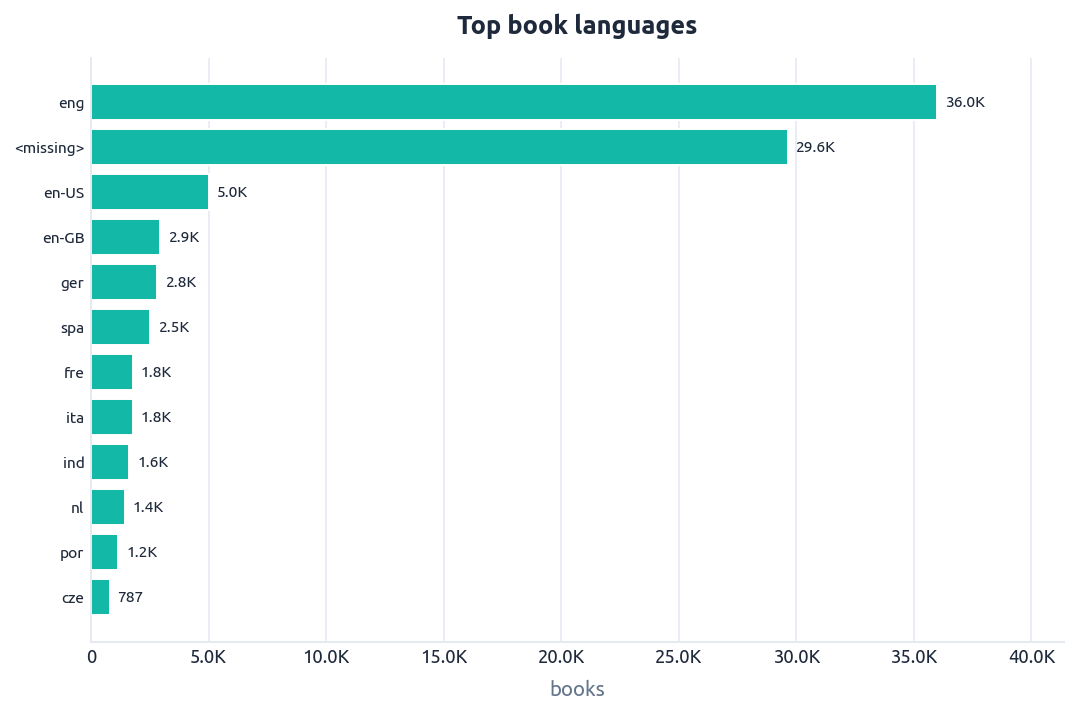

In [18]:
language_dist = q('''SELECT coalesce(language_code, '<missing>') AS language_code, count(*) AS books
FROM books GROUP BY 1 ORDER BY books DESC LIMIT 20''')
hbar(language_dist, "language_code", "books", "Top book languages", "books", COLORS["teal"])
plt.show()

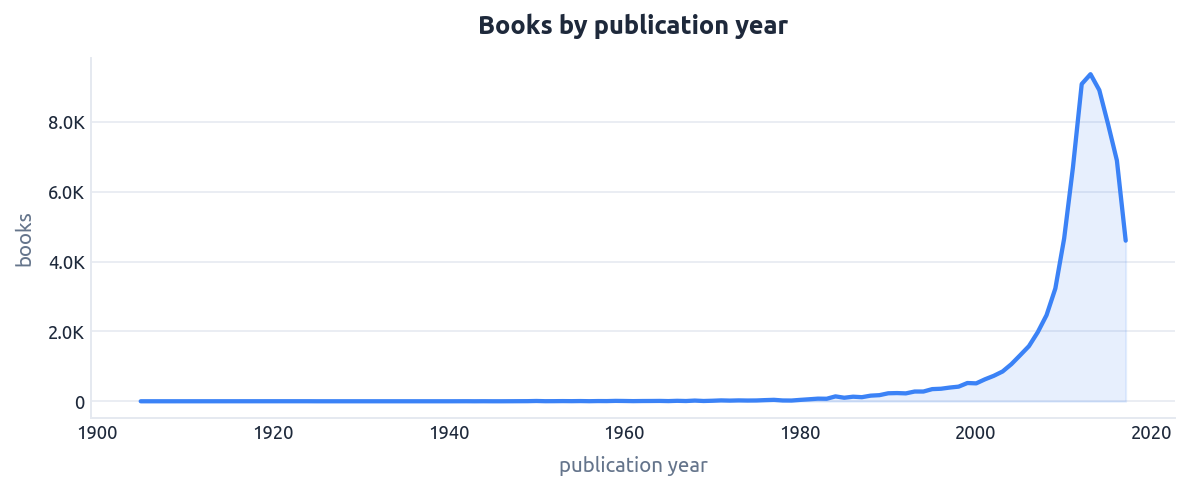

In [19]:
year_dist = q('''SELECT publication_year, count(*) AS books FROM books
WHERE publication_year BETWEEN 1900 AND 2017 GROUP BY 1 ORDER BY 1''')
fig, ax = plt.subplots(figsize=FIG_WIDE)
ax.plot(year_dist.publication_year, year_dist.books, color=COLORS["blue"], lw=2.2)
ax.fill_between(year_dist.publication_year, year_dist.books, color=COLORS["blue"], alpha=0.12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Books by publication year", "publication year", "books")
plt.tight_layout(); plt.show()

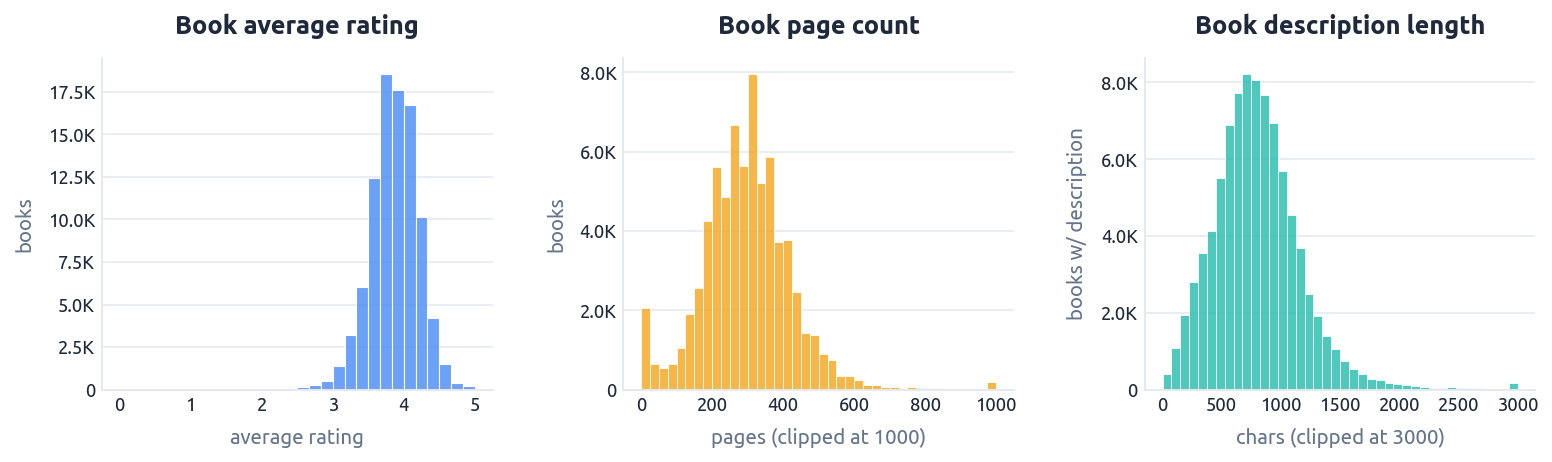

In [20]:
# `description_len` is not on the `books` view (kept only as a derived `has_description` bool).
# Read it directly from the parquet alongside rating / num_pages.
book_numeric = q(f"""SELECT
    try_cast(average_rating AS DOUBLE) AS average_rating,
    try_cast(num_pages AS INTEGER)     AS num_pages,
    description_len
FROM read_parquet({qs(SRC['books'])})
WHERE average_rating IS NOT NULL""")

fig, axes = plt.subplots(1, 3, figsize=FIG_PANEL3)
sns.histplot(book_numeric.average_rating, bins=30, ax=axes[0],
             color=COLORS["blue"], edgecolor="white")
sns.histplot(book_numeric.num_pages.dropna().clip(upper=1000), bins=40, ax=axes[1],
             color=COLORS["amber"], edgecolor="white")
desc_len = book_numeric.description_len.dropna()
desc_len = desc_len[desc_len > 0].clip(upper=3000)
sns.histplot(desc_len, bins=40, ax=axes[2], color=COLORS["teal"], edgecolor="white")
polish(axes[0], "Book average rating",    "average rating",          "books")
polish(axes[1], "Book page count",        "pages (clipped at 1000)", "books")
polish(axes[2], "Book description length","chars (clipped at 3000)", "books w/ description")
for ax in axes: ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
plt.tight_layout(w_pad=2.5); plt.show()

### 5.2 Reviews

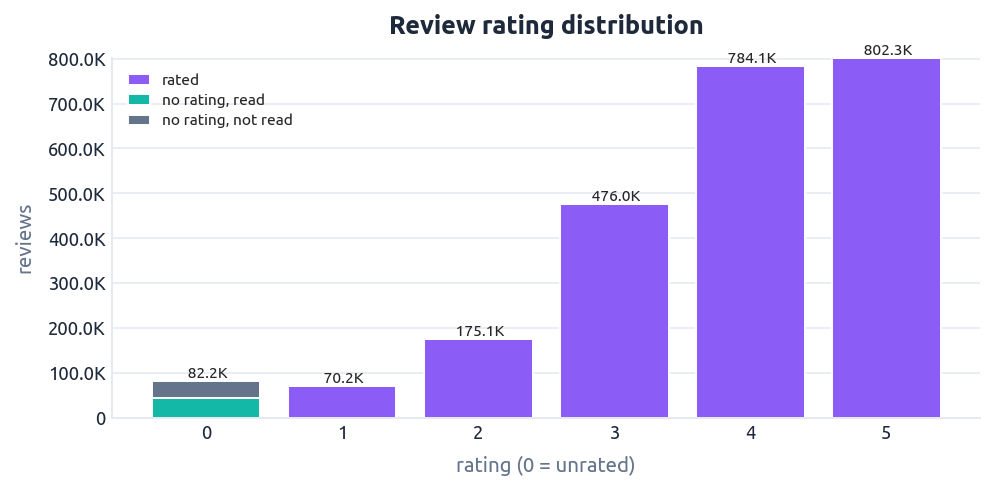

Within rating=0  (82.2K reviews):
  rated                       :       0  (  0.0%)
  no rating, read             :   42.9K  ( 52.2%)
  no rating, not read         :   39.3K  ( 47.8%)


In [21]:
# Reviews don't carry `is_read` directly; join to interactions on review_id to
# split the rating=0 bucket into "read but not rated" vs "shelved but not read".
review_rating_split = q(f"""
    SELECT
        r.rating,
        CASE
            WHEN r.rating > 0      THEN 'rated'
            WHEN i.is_read = TRUE  THEN 'no rating, read'
            WHEN i.is_read = FALSE THEN 'no rating, not read'
            ELSE                        'no rating, status unknown'
        END AS status,
        count(*) AS reviews
    FROM read_parquet({qs(SRC['reviews'])}) r
    LEFT JOIN read_parquet({qs(SRC['interactions'])}) i
        ON i.review_id = r.review_id
    GROUP BY 1, 2
    ORDER BY 1
""")

piv = (review_rating_split
       .pivot(index='rating', columns='status', values='reviews')
       .fillna(0))
status_order = [s for s in ['rated', 'no rating, read',
                            'no rating, not read', 'no rating, status unknown']
                if s in piv.columns]
piv = piv[status_order]
status_color = {'rated':                     COLORS["purple"],
                'no rating, read':           COLORS["teal"],
                'no rating, not read':       COLORS["gray"],
                'no rating, status unknown': COLORS["light_gray"]}

fig, ax = plt.subplots(figsize=FIG_SINGLE)
bottom = np.zeros(len(piv))
for col in piv.columns:
    ax.bar(piv.index.astype(str), piv[col], bottom=bottom,
           color=status_color[col], label=col)
    bottom += piv[col].values
for i, total in enumerate(piv.sum(axis=1).values):
    ax.text(i, total, f" {human(total)}", ha='center', va='bottom', fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Review rating distribution", "rating (0 = unrated)", "reviews")
ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.margins(y=0.2); plt.tight_layout(); plt.show()

# Drill-down: within rating=0, what is the read / not-read mix?
if 0 in piv.index:
    sub = piv.loc[0]
    tot = sub.sum()
    print(f"Within rating=0  ({human(tot)} reviews):")
    for k, v in sub.items():
        print(f"  {k:<28s}: {human(v):>7s}  ({v/tot*100:5.1f}%)")

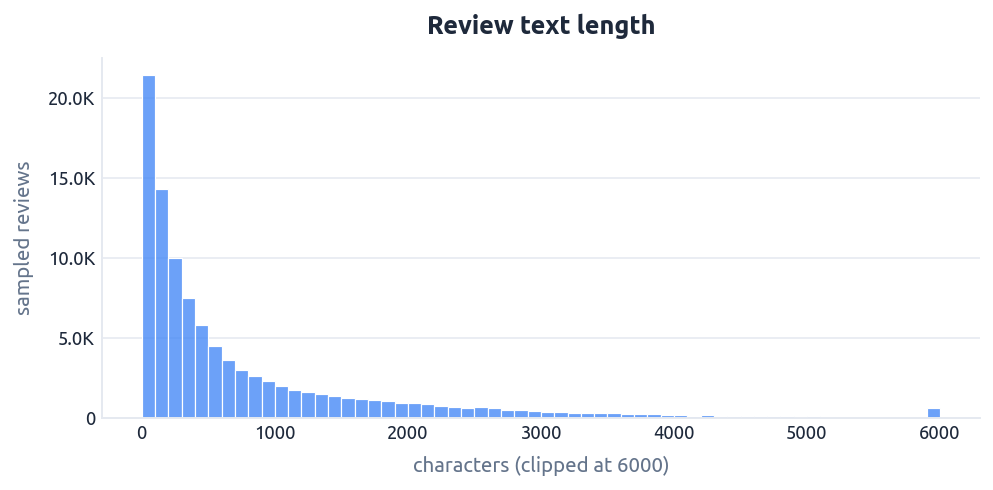

In [22]:
review_len = q('''SELECT review_text_len FROM reviews
WHERE review_text_len IS NOT NULL AND random() < 0.05 LIMIT 100000''')
fig, ax = plt.subplots(figsize=FIG_SINGLE)
sns.histplot(review_len.review_text_len.clip(upper=6000), bins=60, ax=ax,
             color=COLORS["blue"], edgecolor="white")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Review text length", "characters (clipped at 6000)", "sampled reviews")
plt.tight_layout(); plt.show()

**Non-English reviews.** Reviews don't carry a `language` column. A cheap proxy is to look at the ratio of non-ASCII letters per review: anything above ~15% is most likely non-English (CJK, Cyrillic, Arabic). The cell below samples 5K reviews and reports that share — full per-row language detection (`fasttext lid.176`) is the principled fix and runs at ~1 ms / review on CPU, so the downstream pipeline can apply it once and drop non-English rows before any English-only text processing.

In [23]:
# Sample text reviews and flag those with a non-trivial non-ASCII letter
# ratio -- a cheap proxy for non-English. Latin-script non-English (French,
# Spanish) leaks through; the principled downstream fix is fasttext lid.176.
#
# review_text is intentionally NOT kept in reviews_core.parquet (only the
# length + a boolean are projected, to keep the columnar layer small), so we
# stream the raw NDJSON (~2.6 GB) directly and reservoir-sample 5K records.
# The full scan takes a minute or so but only runs once.
import re, random

random.seed(42)
K = 5000
sample_texts = []
with open(RAW_FILES["reviews"]) as f:
    for i, line in enumerate(f):
        rec = json.loads(line)
        t = rec.get("review_text") or ""
        if not (40 <= len(t) <= 5000):
            continue
        if len(sample_texts) < K:
            sample_texts.append(t)
        else:
            j = random.randint(0, i)
            if j < K:
                sample_texts[j] = t

def non_english_proxy(s):
    letters = [c for c in re.sub(r"https?://\S+", "", s) if c.isalpha()]
    if not letters: return False
    non_ascii = sum(1 for c in letters if ord(c) > 127)
    return non_ascii / len(letters) > 0.15

n = len(sample_texts)
flagged = sum(1 for t in sample_texts if non_english_proxy(t))
print(f"Non-ASCII-heavy reviews in {n}-review reservoir sample: {flagged}  ({flagged/n*100:.1f}%)")
print("=> drop them in bundle/ via fasttext lid.176 before any English-only text step.")

Non-ASCII-heavy reviews in 5000-review reservoir sample: 0  (0.0%)
=> drop them in bundle/ via fasttext lid.176 before any English-only text step.


### 5.3 Interactions

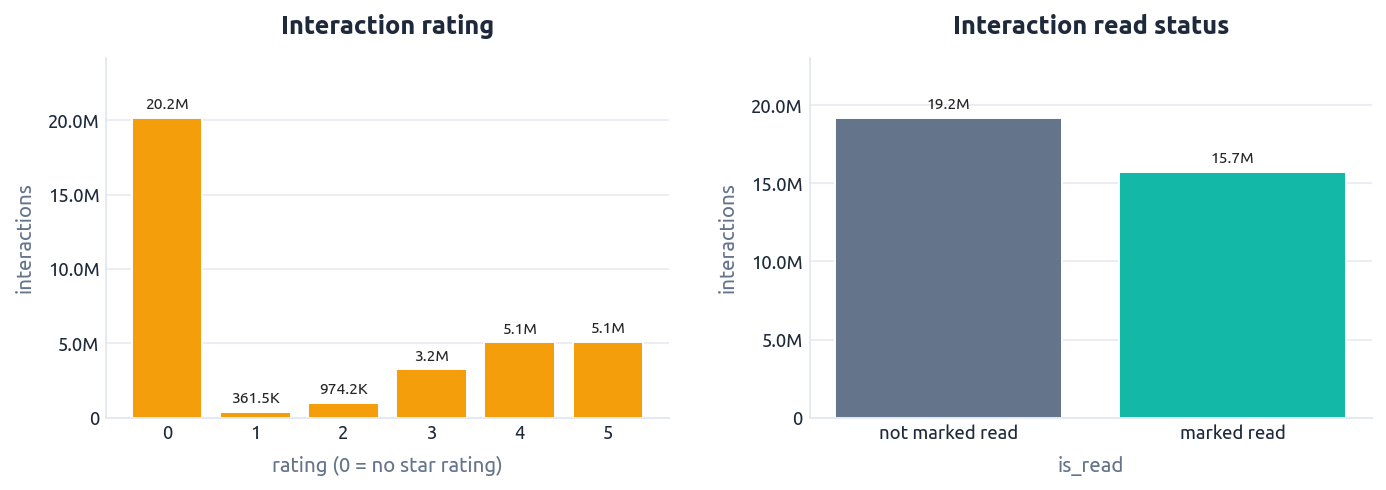

In [24]:
interaction_rating = q("SELECT rating, count(*) AS interactions FROM interactions GROUP BY 1 ORDER BY 1")
is_read = q("SELECT is_read, count(*) AS interactions FROM interactions GROUP BY 1 ORDER BY 1")

fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL2)
b0 = axes[0].bar(interaction_rating.rating.astype(str), interaction_rating.interactions,
                 color=COLORS["amber"])
axes[0].bar_label(b0, labels=[human(v) for v in interaction_rating.interactions],
                  padding=3, fontsize=8)
polish(axes[0], "Interaction rating", "rating (0 = no star rating)", "interactions")

lbl = is_read.is_read.map({False: "not marked read", True: "marked read"}).fillna(is_read.is_read.astype(str))
b1 = axes[1].bar(lbl, is_read.interactions, color=[COLORS["gray"], COLORS["teal"]])
axes[1].bar_label(b1, labels=[human(v) for v in is_read.interactions], padding=3, fontsize=8)
polish(axes[1], "Interaction read status", "is_read", "interactions")

for ax in axes:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
    ax.margins(y=0.2)
plt.tight_layout(w_pad=2.5); plt.show()

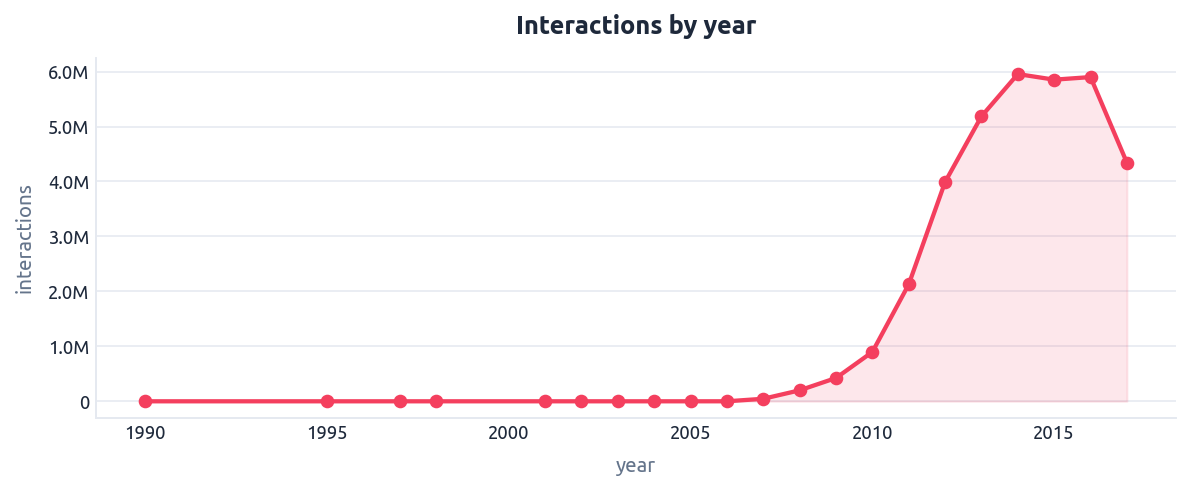

In [25]:
interaction_year = q('''SELECT year(date_added) AS year, count(*) AS interactions
FROM interactions WHERE date_added IS NOT NULL GROUP BY 1 ORDER BY 1''')
fig, ax = plt.subplots(figsize=FIG_WIDE)
ax.plot(interaction_year.year, interaction_year.interactions,
        color=COLORS["coral"], marker="o", lw=2.2)
ax.fill_between(interaction_year.year, interaction_year.interactions,
                color=COLORS["coral"], alpha=0.12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Interactions by year", "year", "interactions")
plt.tight_layout(); plt.show()

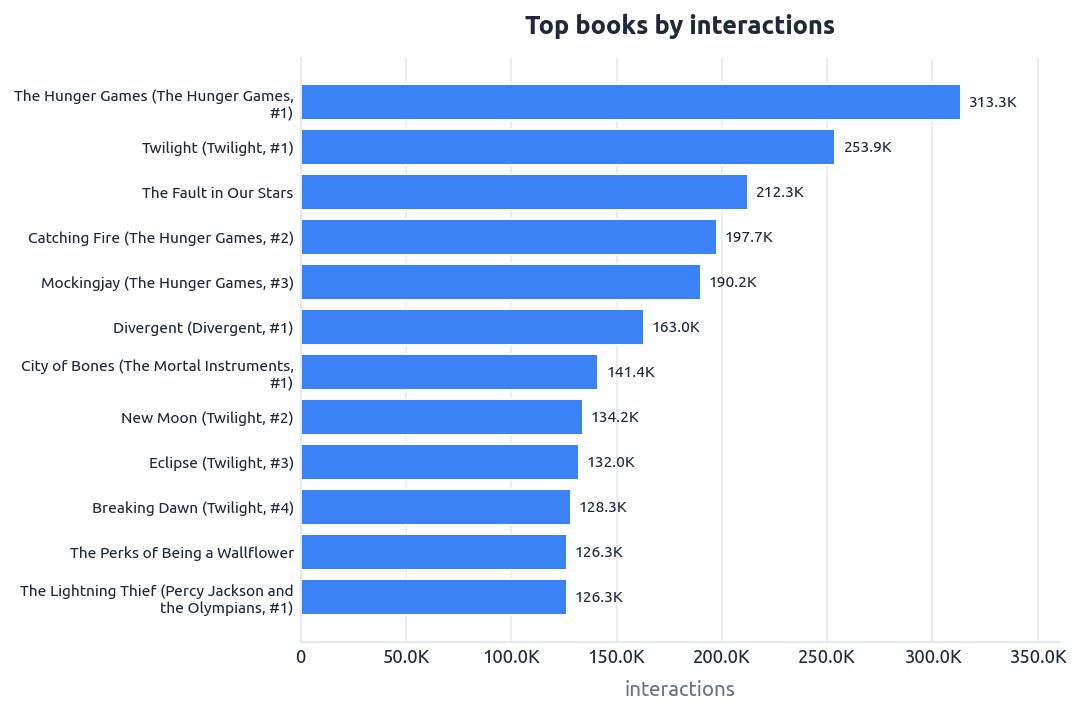

In [26]:
top_books = q('''
WITH per_book AS (SELECT book_id, count(*) AS interactions FROM interactions GROUP BY book_id)
SELECT b.title, p.interactions FROM per_book p LEFT JOIN books b USING (book_id)
ORDER BY p.interactions DESC LIMIT 30''')
hbar(top_books, "title", "interactions", "Top books by interactions", "interactions",
     COLORS["blue"], max_items=12, wrap_width=38)
plt.show()

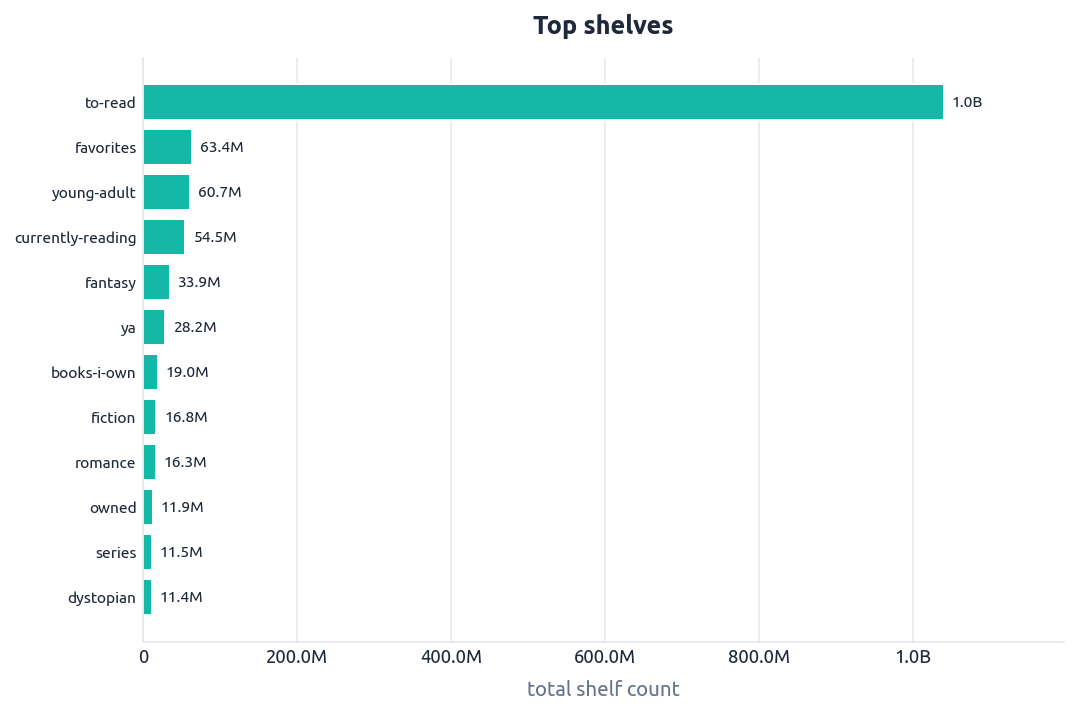

In [27]:
top_shelves = q('''SELECT shelf_name, sum(shelf_count) AS total_shelf_count
FROM book_shelves GROUP BY 1 ORDER BY total_shelf_count DESC LIMIT 30''')
hbar(top_shelves, "shelf_name", "total_shelf_count", "Top shelves",
     "total shelf count", COLORS["teal"], max_items=12, wrap_width=28)
plt.show()

### 5.4 Shelf vocabulary noise

The chart above (raw top-30 shelves) makes shelves look usable — `young-adult`, `fantasy`, `romance` are real content tags. But the raw vocabulary is much bigger than the chart suggests, and most of it is noise. This subsection quantifies that — it's the motivation for the cleanup step in `bundle/encode_tags.py`.

We answer three questions:

1. **How many distinct shelf names exist, and how concentrated is the signal?**
2. **What fraction of the raw top-N is junk** (personal log, ownership, timestamps) rather than content tags?
3. **How much signal is lost to synonyms** (`young-adult` vs `ya` vs `youngadult`)?

In [28]:
shelf_dist = q("""
    SELECT shelf_name,
           sum(shelf_count) AS total_count,    -- weighted: how many users used this shelf
           count(*)         AS n_books         -- in how many books does this shelf appear
    FROM book_shelves
    GROUP BY shelf_name
""")

stats = q("""
    WITH per_shelf AS (
        SELECT shelf_name, count(*) AS n_books_using_it
        FROM book_shelves GROUP BY 1
    )
    SELECT
      count(*)                                                            AS total_unique_shelves,
      sum(CASE WHEN n_books_using_it = 1                       THEN 1 END) AS used_by_1_book,
      sum(CASE WHEN n_books_using_it BETWEEN 2 AND 5           THEN 1 END) AS used_by_2_5_books,
      sum(CASE WHEN n_books_using_it BETWEEN 6 AND 50          THEN 1 END) AS used_by_6_50_books,
      sum(CASE WHEN n_books_using_it BETWEEN 51 AND 500        THEN 1 END) AS used_by_51_500_books,
      sum(CASE WHEN n_books_using_it > 500                     THEN 1 END) AS used_by_500plus_books
    FROM per_shelf
""").iloc[0]

pd.DataFrame({
    "bucket": ["total unique shelf names",
               "used by exactly 1 book   (typos / personal labels)",
               "used by 2-5 books        (long tail)",
               "used by 6-50 books       (niche but multi-user)",
               "used by 51-500 books     (small but real tags)",
               "used by 500+ books       (the durable vocabulary)"],
    "count":  [int(stats.total_unique_shelves),
               int(stats.used_by_1_book),
               int(stats.used_by_2_5_books),
               int(stats.used_by_6_50_books),
               int(stats.used_by_51_500_books),
               int(stats.used_by_500plus_books)],
    "share":  ["100.00%",
               f"{stats.used_by_1_book        / stats.total_unique_shelves * 100:.2f}%",
               f"{stats.used_by_2_5_books     / stats.total_unique_shelves * 100:.2f}%",
               f"{stats.used_by_6_50_books    / stats.total_unique_shelves * 100:.2f}%",
               f"{stats.used_by_51_500_books  / stats.total_unique_shelves * 100:.2f}%",
               f"{stats.used_by_500plus_books / stats.total_unique_shelves * 100:.2f}%"],
})

,bucket,count,share
0,total unique shelf names,217061,100.00%
1,used by exactly 1 book (typos / personal labels),60325,27.79%
2,used by 2-5 books (long tail),96006,44.23%
3,used by 6-50 books (niche but multi-user),52114,24.01%
4,used by 51-500 books (small but real tags),7390,3.40%
5,used by 500+ books (the durable vocabulary),1226,0.56%


**Reading the table.** ~217K distinct shelf names exist, but a *quarter* of them are used by exactly one book — that's almost certainly typos, personal inside-jokes, or one-off labels. Another ~44% are used by 2–5 books. Only **~1.2K shelves** (0.6%) are used by 500+ books, and those are the only ones that look like a usable vocabulary.

Next question: how much of the **weighted signal** (total user-counts, not unique names) is concentrated in those few thousand top shelves?

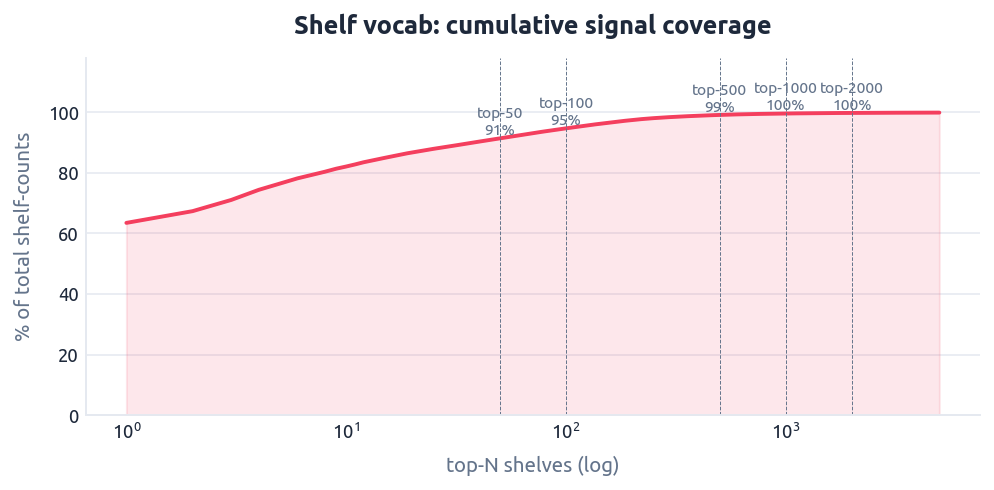

In [29]:
coverage = q("""
    WITH per_shelf AS (
        SELECT shelf_name, sum(shelf_count) AS total FROM book_shelves GROUP BY 1
    ),
    ranked AS (
        SELECT shelf_name, total,
               row_number() OVER (ORDER BY total DESC) AS rk,
               sum(total) OVER ()                       AS grand
        FROM per_shelf
    )
    SELECT rk, sum(total) OVER (ORDER BY rk) / grand AS cumulative_share
    FROM ranked
    WHERE rk <= 5000
""")

fig, ax = plt.subplots(figsize=FIG_SINGLE)
ax.plot(coverage.rk, coverage.cumulative_share * 100, color=COLORS["coral"], lw=2)
ax.fill_between(coverage.rk, coverage.cumulative_share * 100, color=COLORS["coral"], alpha=0.12)
for n in (50, 100, 500, 1000, 2000):
    pct = float(coverage.loc[coverage.rk == n, "cumulative_share"].iloc[0]) * 100
    ax.axvline(n, color=COLORS["gray"], lw=0.5, ls="--")
    ax.text(n, pct + 1, f"top-{n}\n{pct:.0f}%", ha="center", fontsize=8, color=COLORS["gray"])
ax.set_xscale("log")
ax.set_ylim(0, 118)
polish(ax, "Shelf vocab: cumulative signal coverage",
       "top-N shelves (log)", "% of total shelf-counts")
plt.tight_layout(); plt.show()

**Top-100 covers ~95%; top-500 covers ~99%.** A curated vocab of a few hundred entries is enough to capture almost all the content signal — provided you actually clean it. That's the headline number for sizing the tag vocab.

The remaining issue is *which* entries to pick from the top-N. The next chart breaks down the **raw top-25** by category — some of the most-used shelves aren't content at all.

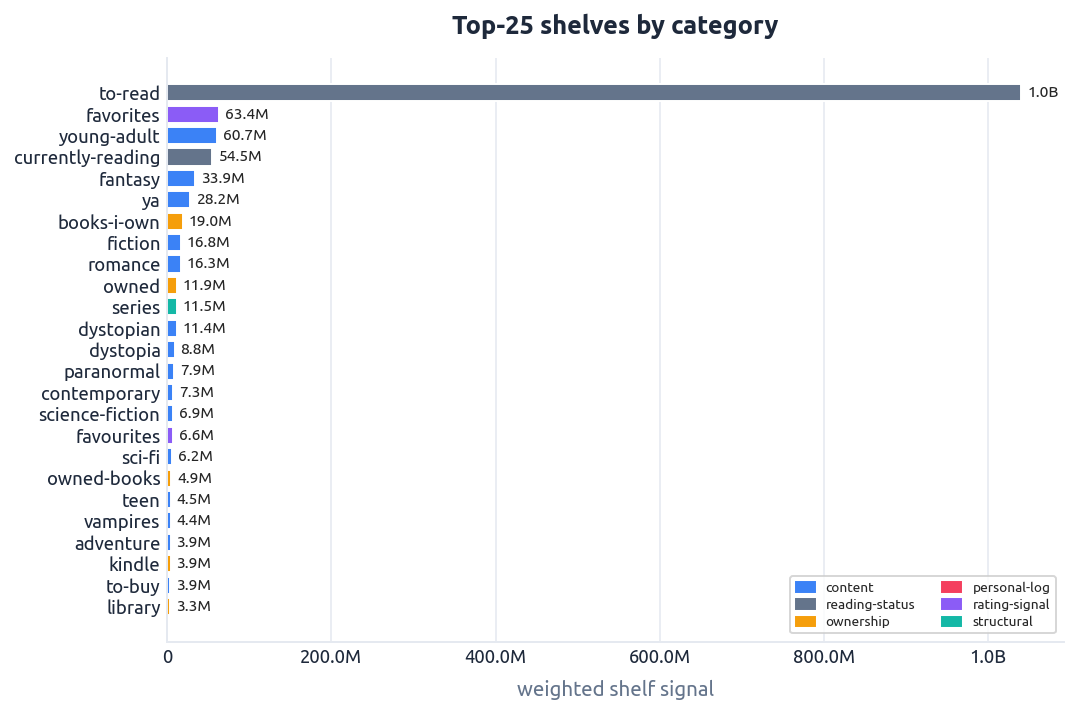

,shelf_name,total,category
0,to-read,1.040279e+09,reading-status
1,favorites,6.337358e+07,rating-signal
2,young-adult,6.069527e+07,content
3,currently-reading,5.449012e+07,reading-status
4,fantasy,3.391256e+07,content
5,ya,2.821541e+07,content
6,books-i-own,1.902269e+07,ownership
7,fiction,1.678781e+07,content
8,romance,1.633494e+07,content
9,owned,1.192934e+07,ownership


In [30]:
top25 = q("""
    SELECT shelf_name, sum(shelf_count) AS total
    FROM book_shelves GROUP BY 1 ORDER BY total DESC LIMIT 25
""")

# Light classification of why a shelf might NOT be a content tag.
import re
def categorise(name):
    n = name.lower()
    if n in {"to-read", "currently-reading", "read", "reading"}: return "reading-status"
    if re.match(r"^(books-i-|i-own|own|owned|kindle|library|ebooks?|my-books|on-my)", n) or n.endswith("-shelf"): return "ownership"
    if re.match(r"^(read-in|re-read|finished|read-)", n) or re.search(r"20[01]\d", n):                          return "personal-log"
    if n in {"favorites", "favourites"}:                                                                          return "rating-signal"
    if n in {"series", "trilogy", "standalone"}:                                                                  return "structural"
    return "content"

top25["category"] = top25["shelf_name"].apply(categorise)
cat_colors = {"content": COLORS["blue"], "reading-status": COLORS["gray"],
              "ownership": COLORS["amber"], "personal-log": COLORS["coral"],
              "rating-signal": COLORS["purple"], "structural": COLORS["teal"]}

fig, ax = plt.subplots(figsize=FIG_HBAR_TALL)
order = top25.sort_values("total")
bars = ax.barh(order.shelf_name, order.total, color=[cat_colors[c] for c in order.category])
ax.bar_label(bars, labels=[human(v) for v in order.total], padding=3, fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Top-25 shelves by category", "weighted shelf signal", grid_axis="x")

handles = [plt.Rectangle((0,0),1,1, color=c) for c in cat_colors.values()]
ax.legend(handles, list(cat_colors.keys()), loc="lower right", ncol=2, fontsize=7, frameon=True)
plt.tight_layout(); plt.show()
display(top25)

**Out of the raw top-25, only about half are content tags.** The rest are reading-status (`to-read`, `currently-reading`), ownership (`books-i-own`, `owned`, `kindle`), or rating signals (`favorites` / `favourites`). For any tag-based downstream use, all of those should be filtered out of the vocab — they describe *what the user did with the book*, not *what the book is about*.

`favorites` vs `favourites` is also a hint at the next problem: **synonym fragmentation**.

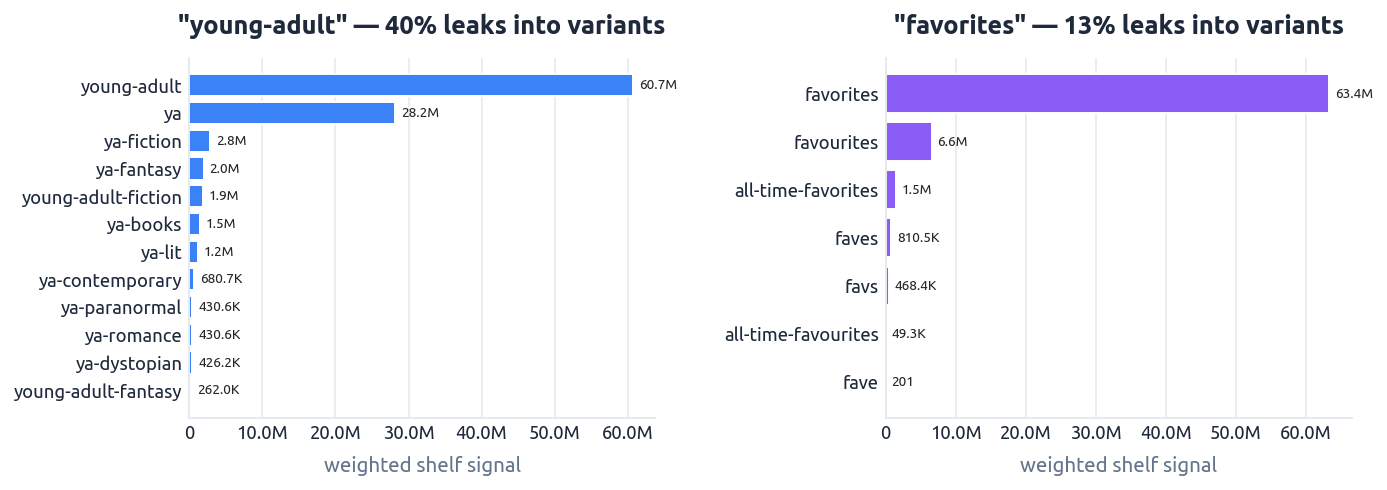

In [31]:
# Pick a couple of obviously-fragmented concepts and show how much signal is
# split across spelling / abbreviation variants. Pattern matching here is
# illustrative -- the real synonym table lives in bundle/encode_tags.py.
synonyms = q("""
    SELECT shelf_name, sum(shelf_count) AS total
    FROM book_shelves
    WHERE shelf_name ILIKE '%young%adult%' OR shelf_name IN ('ya','ya-fiction','ya-books','ya-lit','youngadult','y-a')
       OR shelf_name LIKE 'ya-%'
    GROUP BY 1 ORDER BY total DESC LIMIT 12
""")
synonyms["concept"] = "young-adult"

others = q("""
    SELECT shelf_name, sum(shelf_count) AS total
    FROM book_shelves
    WHERE shelf_name IN ('favorites','favourites','favs','fave','faves','all-time-favorites','all-time-favourites')
    GROUP BY 1 ORDER BY total DESC LIMIT 12
""")
others["concept"] = "favorites"

merged = pd.concat([synonyms, others], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=FIG_PANEL2)
for ax, concept, color in zip(axes, ["young-adult", "favorites"], [COLORS["blue"], COLORS["purple"]]):
    sub = merged[merged.concept == concept].sort_values("total")
    bars = ax.barh(sub.shelf_name, sub.total, color=color)
    ax.bar_label(bars, labels=[human(v) for v in sub.total], padding=3, fontsize=7)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
    canonical = sub.iloc[-1]["total"]
    others_sum = sub.iloc[:-1]["total"].sum()
    leak_pct = others_sum / (canonical + others_sum) * 100
    polish(ax, f"\"{concept}\" — {leak_pct:.0f}% leaks into variants",
           "weighted shelf signal", grid_axis="x")
plt.tight_layout(w_pad=2.5); plt.show()

For *young-adult*, ~40% of the weighted signal sits in non-canonical spellings (`ya`, `ya-fiction`, `youngadult`, ...). For *favorites* the British `favourites` alone is 10%. Without a synonym pass, any tag vocab built directly from the top-N shelf list will treat these as different concepts.

### Implications for vocab construction

This noise analysis gives us three concrete numbers for `bundle/encode_tags.py`:

| Decision | Choice driven by this data |
|---|---|
| **Vocab size** | ~300–500 entries. Top-500 captures 99% of weighted signal; going wider mostly adds noise. |
| **Shelves to drop before building the vocab** | `to-read`, `currently-reading`, `read`, ownership (`books-i-own`, `kindle`, `library`, …), personal logs (`read-in-2014`, …), pure structural tags (`series`, `trilogy`). |
| **Synonym merging required** | Yes — at minimum a manual map for the top ~50 concepts (YA variants, US/UK spellings, abbreviations). Stemming alone isn't enough (`fave` ↛ `favorites`). |

## 6. Cold-start & long-tail

This is the part that drives the recall architecture. Per-user and per-item interaction counts are pulled once into NumPy and concentration metrics are computed from them.

In [32]:
user_counts = q("SELECT count(*) AS n FROM interactions GROUP BY user_id")["n"].to_numpy()
item_counts = q("SELECT count(*) AS n FROM interactions GROUP BY book_id")["n"].to_numpy()
print(f"users: {user_counts.size:,}   items: {item_counts.size:,}")

users: 644,686   items: 93,398


### 6.1 Activity buckets — share of entities vs share of interactions

,entities,interactions,pct_entities,pct_interactions
bucket,,,,
1-5 (cold),216220,520987,0.335388,0.014920
6-20,167604,1916448,0.259978,0.054882
21-50,106625,3509365,0.165391,0.100499
51-100,66919,4798605,0.103801,0.137420
101-500,78436,15945053,0.121665,0.456626
500+ (hot),8882,8228796,0.013777,0.235652


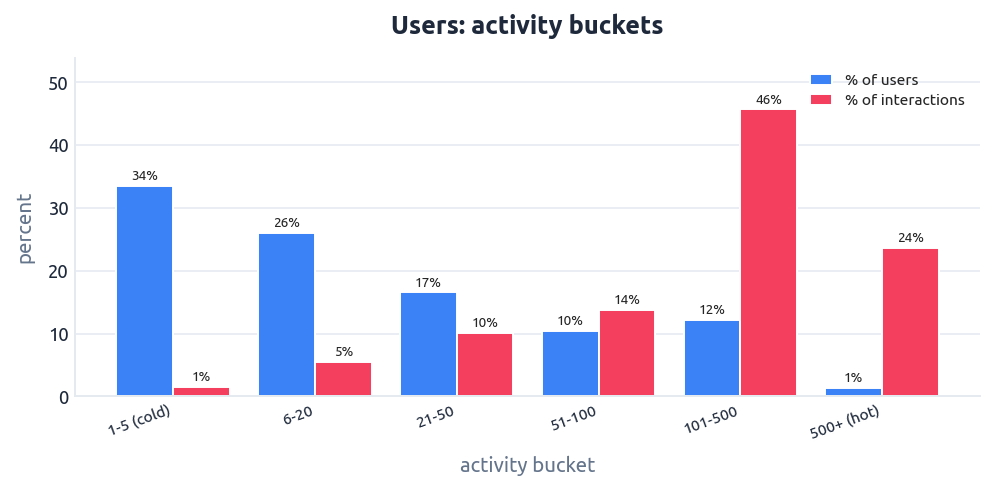

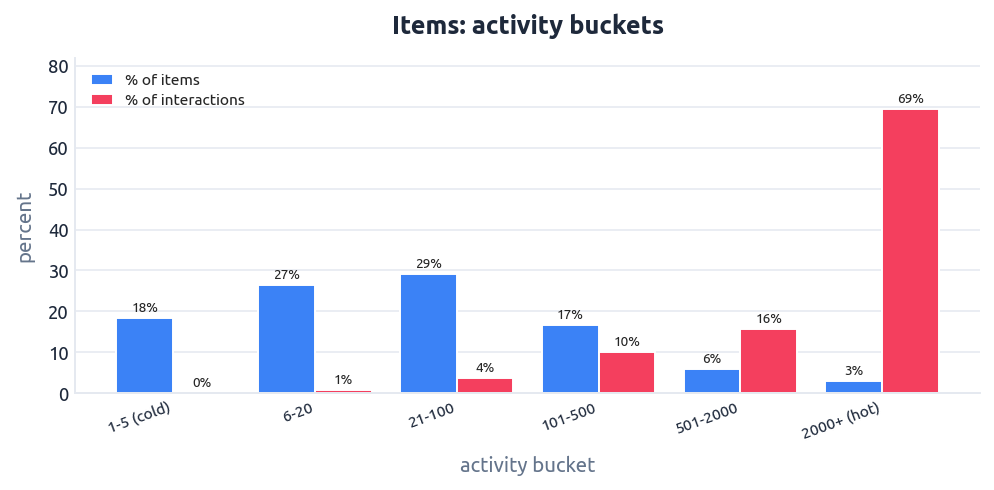

In [33]:
def bucketize(counts, edges, labels):
    idx = np.digitize(counts, edges, right=True)
    df = pd.DataFrame({"bucket": [labels[i] for i in idx], "n": counts})
    g = (df.groupby("bucket", sort=False)
           .agg(entities=("n", "size"), interactions=("n", "sum"))
           .reindex(labels).dropna())
    g["pct_entities"]     = g.entities     / g.entities.sum()
    g["pct_interactions"] = g.interactions / g.interactions.sum()
    return g

user_buckets = bucketize(user_counts, [5, 20, 50, 100, 500],
                         ["1-5 (cold)", "6-20", "21-50", "51-100", "101-500", "500+ (hot)"])
item_buckets = bucketize(item_counts, [5, 20, 100, 500, 2000],
                         ["1-5 (cold)", "6-20", "21-100", "101-500", "501-2000", "2000+ (hot)"])

def grouped_share(g, title, ent_word):
    x = np.arange(len(g)); w = 0.4
    fig, ax = plt.subplots(figsize=FIG_SINGLE)
    b1 = ax.bar(x - w/2, g.pct_entities*100,     w, label=f"% of {ent_word}", color=COLORS["blue"])
    b2 = ax.bar(x + w/2, g.pct_interactions*100, w, label="% of interactions", color=COLORS["coral"])
    for b in (b1, b2):
        ax.bar_label(b, labels=[f"{v:.0f}%" for v in b.datavalues], padding=2, fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(g.index, rotation=20, ha="right", fontsize=8)
    polish(ax, title, "activity bucket", "percent")
    ax.legend(fontsize=8); ax.margins(y=0.18); plt.tight_layout(); plt.show()

display(user_buckets)
grouped_share(user_buckets, "Users: activity buckets", "users")
grouped_share(item_buckets, "Items: activity buckets", "items")

### 6.2 Head concentration — how few items carry the volume

,items,users
top 0.1%,19.2%,5.0%
top 1%,50.3%,19.8%
top 5%,77.0%,45.5%
top 10%,86.3%,61.6%
top 20%,93.3%,78.8%


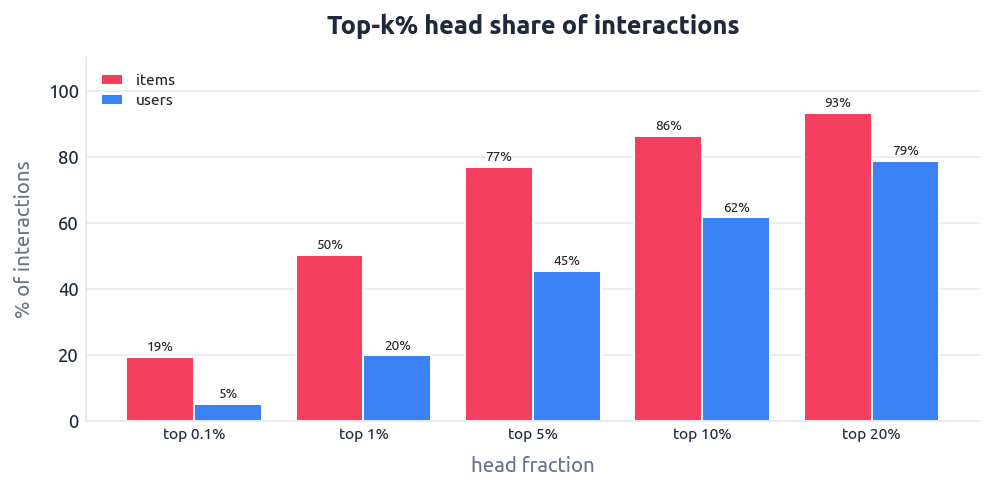

In [34]:
def head_share(counts, fracs=(0.001, 0.01, 0.05, 0.10, 0.20)):
    s = np.sort(counts)[::-1]; tot = s.sum(); n = s.size
    return {f"top {f*100:g}%": s[:max(1, int(round(f*n)))].sum() / tot for f in fracs}

head_df = pd.DataFrame({"items": head_share(item_counts), "users": head_share(user_counts)})
x = np.arange(len(head_df)); w = 0.4
fig, ax = plt.subplots(figsize=FIG_SINGLE)
b1 = ax.bar(x - w/2, head_df["items"]*100, w, label="items", color=COLORS["coral"])
b2 = ax.bar(x + w/2, head_df["users"]*100, w, label="users", color=COLORS["blue"])
for b in (b1, b2):
    ax.bar_label(b, labels=[f"{v:.0f}%" for v in b.datavalues], padding=2, fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(head_df.index, fontsize=8)
polish(ax, "Top-k% head share of interactions", "head fraction", "% of interactions")
ax.legend(loc='upper left', fontsize=8); ax.margins(y=0.18)
display(head_df.style.format("{:.1%}"))
plt.tight_layout(); plt.show()

### 6.3 Cold-start inflow over time

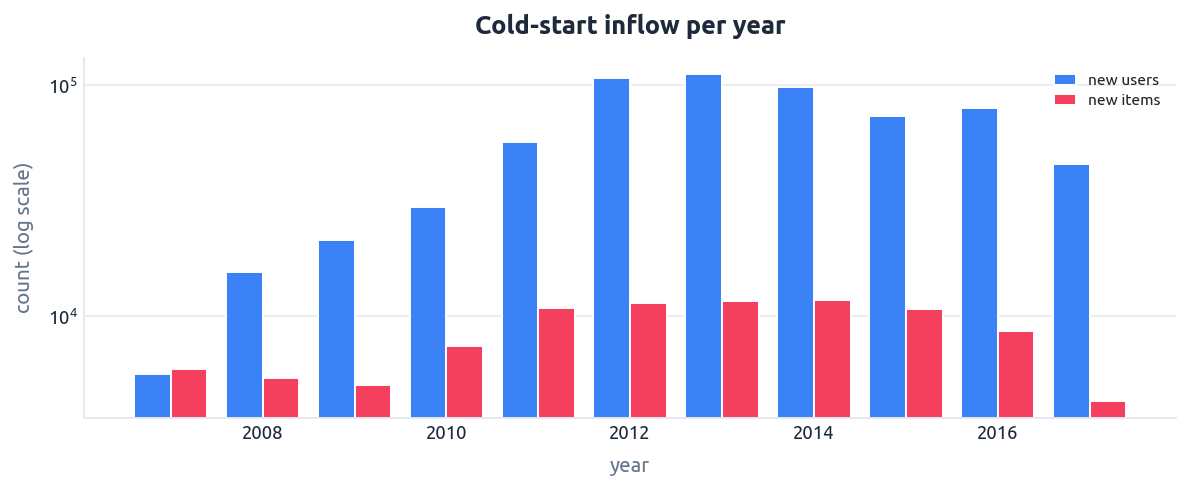

In [35]:
new_users = q('''WITH f AS (SELECT user_id, min(date_added) d FROM interactions WHERE date_added IS NOT NULL GROUP BY user_id)
SELECT year(d) AS year, count(*) AS new_users FROM f GROUP BY 1 ORDER BY 1''')
new_items = q('''WITH f AS (SELECT book_id, min(date_added) d FROM interactions WHERE date_added IS NOT NULL GROUP BY book_id)
SELECT year(d) AS year, count(*) AS new_items FROM f GROUP BY 1 ORDER BY 1''')
m = new_users.merge(new_items, on="year", how="outer").sort_values("year")
m = m[(m.year >= 2007) & (m.year <= 2017)]
fig, ax = plt.subplots(figsize=FIG_WIDE)
ax.bar(m.year - 0.2, m.new_users, 0.4, label="new users", color=COLORS["blue"])
ax.bar(m.year + 0.2, m.new_items, 0.4, label="new items", color=COLORS["coral"])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Cold-start inflow per year", "year", "count (log scale)")
ax.set_yscale("log"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 6.4 Signals available for cold-start & supervision

Two complementary views: *what side information do we have on cold items / users so a content-based fallback has something to work with?* (left), and *how strong is the supervision signal on the average interaction row?* (right).

,coverage
user: wrote >=5 reviews,12.3%
user: wrote >=1 review,32.4%
interaction: has star rating,42.2%
book: in a series,58.5%
book: has description,95.4%
book: has shelves,100.0%
book: has author,100.0%


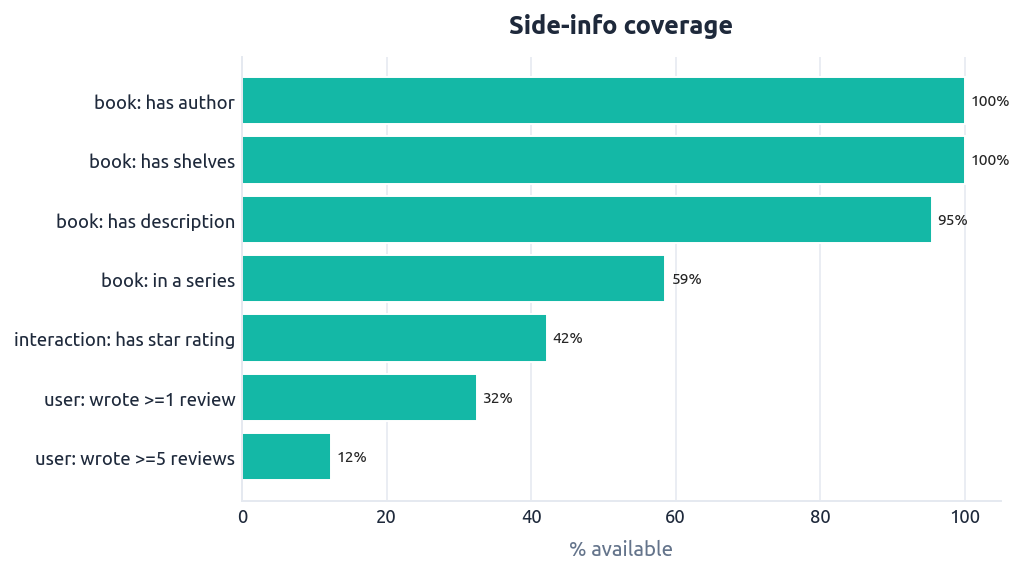

In [36]:
sig = {}
b = q('''SELECT count(*) n,
  sum(CASE WHEN has_description THEN 1 ELSE 0 END) desc_,
  sum(CASE WHEN series_count > 0 THEN 1 ELSE 0 END) series_,
  sum(CASE WHEN popular_shelves_count > 0 THEN 1 ELSE 0 END) shelves_,
  sum(CASE WHEN authors_count > 0 THEN 1 ELSE 0 END) authors_ FROM books''').iloc[0]
sig["book: has description"] = b.desc_ / b.n
sig["book: in a series"]     = b.series_ / b.n
sig["book: has shelves"]     = b.shelves_ / b.n
sig["book: has author"]      = b.authors_ / b.n
ru = q('''WITH p AS (SELECT user_id, count(*) c FROM reviews WHERE has_review_text GROUP BY user_id)
SELECT (SELECT count(DISTINCT user_id) FROM interactions) tot,
       sum(CASE WHEN c>=1 THEN 1 ELSE 0 END) ge1, sum(CASE WHEN c>=5 THEN 1 ELSE 0 END) ge5 FROM p''').iloc[0]
sig["user: wrote >=1 review"]  = ru.ge1 / ru.tot
sig["user: wrote >=5 reviews"] = ru.ge5 / ru.tot
sig["interaction: has star rating"] = q("SELECT avg(CASE WHEN rating>0 THEN 1.0 ELSE 0.0 END) r FROM interactions").iloc[0].r

sig_df = pd.Series(sig).sort_values()
fig, ax = plt.subplots(figsize=FIG_HBAR)
bars = ax.barh(sig_df.index, sig_df.values*100, color=COLORS["teal"])
ax.bar_label(bars, labels=[f"{v*100:.0f}%" for v in sig_df.values], padding=3, fontsize=8)
polish(ax, "Side-info coverage", "% available", grid_axis="x")
ax.set_xlim(0, 105); display(sig_df.to_frame("coverage").style.format("{:.1%}"))
plt.tight_layout(); plt.show()

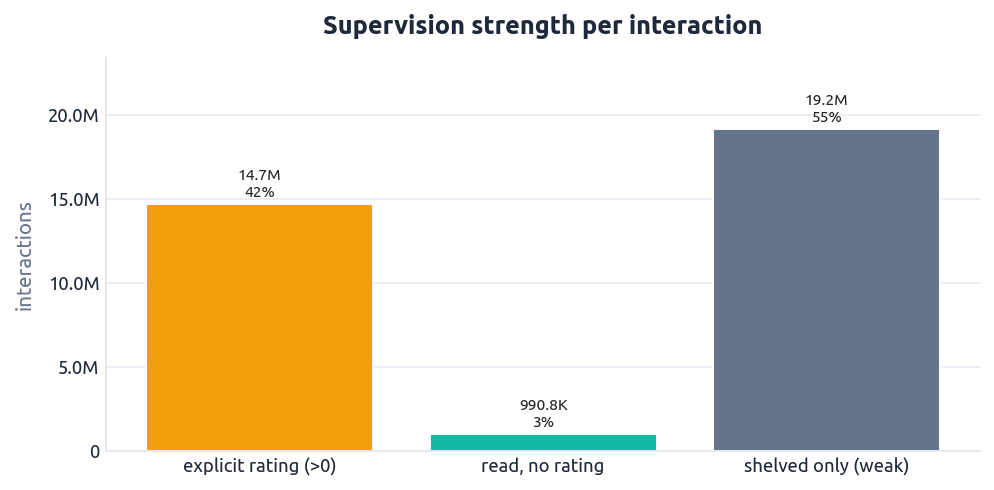

In [37]:
st = q('''SELECT
  sum(CASE WHEN rating > 0 THEN 1 ELSE 0 END) AS has_rating,
  sum(CASE WHEN rating = 0 AND is_read THEN 1 ELSE 0 END) AS read_no_rating,
  sum(CASE WHEN rating = 0 AND NOT is_read THEN 1 ELSE 0 END) AS shelved_only FROM interactions''').iloc[0]
parts = pd.Series({"explicit rating (>0)": st.has_rating,
                   "read, no rating":      st.read_no_rating,
                   "shelved only (weak)":  st.shelved_only})
fig, ax = plt.subplots(figsize=FIG_SINGLE)
bars = ax.bar(parts.index, parts.values, color=[COLORS["amber"], COLORS["teal"], COLORS["gray"]])
ax.bar_label(bars, labels=[f"{human(v)}\n{v/parts.sum()*100:.0f}%" for v in parts.values],
             padding=2, fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: human(x)))
polish(ax, "Supervision strength per interaction", None, "interactions")
ax.margins(y=0.22); plt.tight_layout(); plt.show()

## 7. LLM profiles (v2, bge-oriented) — coverage, lengths, samples

Profiling was redesigned to be **leakage-free** (split-first, train-only reviews, most-recent, positive+negative) and **bge-friendly**: free-text `taste`/`avoid` per user and a `profile` per item (`profiling/data/v2/`), encoded by bge into the item-content space. The old tag/vocab/`level`/`rating_bias` profiling is deprecated. Modeling results: see `retrieval/REPORT_v3.md` (user) and `REPORT_v4.md` (item).

In [38]:
import json as _json
V2 = PROJECT_DIR / 'profiling' / 'data' / 'v2'
def _load(p): return [_json.loads(l) for l in open(p) if l.strip()]
uprof = _load(V2 / 'user_profiles.jsonl')   # {uid, taste, avoid}
iprof = _load(V2 / 'item_profiles.jsonl')   # {iid, profile}
n_users = q("SELECT count(DISTINCT user_id) AS n FROM interactions")['n'].iloc[0]
u_ok = sum('taste' in r for r in uprof); i_ok = sum('profile' in r for r in iprof)
pd.DataFrame({
    'side': ['user (taste/avoid)', 'item (profile)'],
    'profiled': [len(uprof), len(iprof)],
    'parse_ok': [u_ok, i_ok],
    'coverage': [f'{len(uprof)/n_users*100:.1f}% of {int(n_users):,} users (>=3 train reviews)',
                 f'{i_ok:,} of all works'],
})

,side,profiled,parse_ok,coverage
0,user (taste/avoid),98662,98662,"15.3% of 644,686 users (>=3 train reviews)"
1,item (profile),34916,34916,"34,916 of all works"


### 7.1 Profile text lengths (words)

In [39]:
import numpy as _np
_wl = lambda s: len((s or '').split())
ut = [_wl(r.get('taste','')) for r in uprof if 'taste' in r]
ua = [_wl(r.get('avoid','')) for r in uprof if 'taste' in r]
ip = [_wl(r.get('profile','')) for r in iprof if 'profile' in r]
pct_empty_avoid = _np.mean([x == 0 for x in ua]) * 100
print(f'users with empty avoid (no disliked tendencies extracted): {pct_empty_avoid:.0f}%')
pd.DataFrame({'field': ['user taste','user avoid','item profile'],
    'mean_words': [_np.mean(ut), _np.mean(ua), _np.mean(ip)],
    'p50': [_np.median(ut), _np.median(ua), _np.median(ip)],
    'p90': [_np.percentile(ut,90), _np.percentile(ua,90), _np.percentile(ip,90)]}).round(1)

users with empty avoid (no disliked tendencies extracted): 43%


,field,mean_words,p50,p90
0,user taste,24.7,25.0,32.0
1,user avoid,8.1,9.0,19.0
2,item profile,37.0,37.0,45.0


### 7.2 Sample profiles

In [40]:
titles = pd.read_parquet(V2 / 'item_inputs.parquet').set_index('iid')['title'].to_dict()
print('=== USER taste / avoid ===')
for r in uprof[:3]:
    if 'taste' in r:
        print(f"  uid {r['uid']}")
        print(f"    taste: {r['taste']}")
        print(f"    avoid: {r.get('avoid') or '(none)'}")
print('\n=== ITEM profile ===')
for r in iprof[:3]:
    if 'profile' in r:
        print(f"  [{r['iid']}] {titles.get(r['iid'],'?')[:55]}")
        print(f"    {r['profile']}")

=== USER taste / avoid ===
  uid 5
    taste: Fast-paced young adult dystopian thrillers featuring high-stakes survival, political intrigue, and intense action sequences that keep readers on the edge of their seats.
    avoid: Teen romance subplots, slow-burn emotional drama, and overly sentimental or melodramatic storytelling.
  uid 7
    taste: A reader who deeply connects with nostalgic, character-driven stories that evoke a sense of youth and realness, particularly in dystopian romances and urban fantasy series featuring strong sexual tension and emotional resonance.
    avoid: Audio books with poor acting, clichéd plots, jumpy pacing, and stories lacking character connection or suspense.
  uid 14
    taste: A poetic, emotionally resonant, and often strange or unconventional narrative that explores deep human experiences with a unique, memorable voice.
    avoid: (none)

=== ITEM profile ===
  [0] Pies & Prejudice (The Mother-Daughter Book Club, #4)
    A heartwarming contemporary 